# Model training + analysis of data (old split)

## Data loading

In [193]:
all_subjects = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]

test_subjects = [17, 18, 19, 20, 21, 22] 

remaining_subjects = [s for s in all_subjects if s not in test_subjects]

train_subjects = remaining_subjects[:11] 

val_subjects = remaining_subjects[11:]

print(f"Train ({len(train_subjects)}): {train_subjects}")
print(f"Val ({len(val_subjects)}): {val_subjects}")
print(f"Test ({len(test_subjects)}): {test_subjects}")

Train (11): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Val (5): [12, 13, 14, 15, 16]
Test (6): [17, 18, 19, 20, 21, 22]


In [194]:
def segment_data(df, subjects, w=2, o=0.75, fs=60):
    win_size = int(w * fs)
    step = int(win_size * (1 - o))
    
    # Order matters for the Multi-Branch CNN: 8 Ankle channels first, 4 Back channels last
    cols = [
        'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
        'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
        'back_q0', 'back_q1', 'back_q2', 'back_q3'
    ]
    
    X, y = [], []
    
    for sub in subjects:
        sub_df = df[df['subjectID'] == sub].reset_index(drop=True)
        data = sub_df[cols].values
        labels = sub_df['fog'].values
        
        for i in range(0, len(data) - win_size, step):
            window = data[i : i + win_size]
            # --- RELATIVE TRANSFORMATION ---
            # Subtract the first sample of the window from the whole window
            window_rel = window - window[0]
            
            X.append(window_rel)
            # Use the mode (most frequent) label for the window
            y.append(pd.Series(labels[i : i + win_size]).mode()[0])
            
    return np.array(X), np.array(y)

# Load your generated quaternions file
df_quat = pd.read_csv('sensor_data_quaternions.csv')

print("Segmenting datasets...")
X_train, y_train = segment_data(df_quat, train_subjects)
X_val, y_val     = segment_data(df_quat, val_subjects)
X_test, y_test   = segment_data(df_quat, test_subjects)

Segmenting datasets...


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class FogDataset(Dataset):
    def __init__(self, X, y):
        # Convert to float32 and move to tensors
        # X shape from segmentation: (Samples, Time, Channels) -> e.g., (N, 120, 12)
        # PyTorch Conv1d expects: (Samples, Channels, Time) -> e.g., (N, 12, 120)
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = FogDataset(X_train, y_train)
val_dataset = FogDataset(X_val, y_val)
test_dataset = FogDataset(X_test, y_test)

# DataLoader handles batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [196]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate weights for the loss function
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# Convert to a tensor for PyTorch (pos_weight for BCEWithLogitsLoss)
pos_weight = torch.tensor([weights[1] / weights[0]], dtype=torch.float32).to(device)

print(f"Class weights: {weights} | Pos_weight: {pos_weight.item():.2f}")

Class weights: [0.64274792 2.25133894] | Pos_weight: 3.50


## Model architecture and training

In [197]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiBranchCNN(nn.Module):
    def __init__(self):
        super(MultiBranchCNN, self).__init__()
        
        # Branch 1: Ankles (8 channels: Left q0-q3 + Right q0-q3)
        self.ankle_branch = nn.Sequential(
            nn.Conv1d(8, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.5),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # Reduces to a single vector
        )
        
        # Branch 2: Back (4 channels: Back q0-q3)
        self.back_branch = nn.Sequential(
            nn.Conv1d(4, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.5),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Fusion Layer: Combines 128 (Ankles) + 64 (Back) = 192 features
        self.classifier = nn.Sequential(
            nn.Linear(192, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x is assumed to be (Batch, Channels, Time) -> (Batch, 12, 120)
        ankles = x[:, 0:8, :] # First 8 channels
        back = x[:, 8:12, :]  # Last 4 channels
        
        feat_ankles = self.ankle_branch(ankles).view(x.size(0), -1)
        feat_back = self.back_branch(back).view(x.size(0), -1)
        
        # Concatenate branches
        combined = torch.cat((feat_ankles, feat_back), dim=1)
        return self.classifier(combined)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = MultiBranchCNN().to(device)
print(f"Model initialized on: {device}")

Model initialized on: mps


In [ ]:
import numpy as np

def train_model(model, train_loader, val_loader, epochs=50, lr=0.001):
    # Setup Optimizer and Loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    #criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    criterion = nn.BCELoss()
    #criterion = FocalLoss(alpha=0.75, gamma=2.0)

    # Scheduler: Reduces LR if validation loss doesn't improve for 5 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                v_loss = criterion(outputs, labels)
                val_losses.append(v_loss.item())
        
        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        
        # Update Scheduler
        scheduler.step(avg_val_loss)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Save Best Model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_multibranch_model_quat.pth')
            print("--> Model Saved!")

train_model(model, train_loader, val_loader)

Epoch 1/50 | Train Loss: 0.4349 | Val Loss: 0.2511 | LR: 0.001000
--> Model Saved!
Epoch 2/50 | Train Loss: 0.3534 | Val Loss: 0.2693 | LR: 0.001000
Epoch 3/50 | Train Loss: 0.3394 | Val Loss: 0.2763 | LR: 0.001000
Epoch 4/50 | Train Loss: 0.3308 | Val Loss: 0.2768 | LR: 0.001000
Epoch 5/50 | Train Loss: 0.3253 | Val Loss: 0.2547 | LR: 0.001000
Epoch 6/50 | Train Loss: 0.3252 | Val Loss: 0.2480 | LR: 0.001000
--> Model Saved!
Epoch 7/50 | Train Loss: 0.3089 | Val Loss: 0.2352 | LR: 0.001000
--> Model Saved!
Epoch 8/50 | Train Loss: 0.3055 | Val Loss: 0.2469 | LR: 0.001000
Epoch 9/50 | Train Loss: 0.2947 | Val Loss: 0.2266 | LR: 0.001000
--> Model Saved!
Epoch 10/50 | Train Loss: 0.2858 | Val Loss: 0.2372 | LR: 0.001000
Epoch 11/50 | Train Loss: 0.2879 | Val Loss: 0.2347 | LR: 0.001000
Epoch 12/50 | Train Loss: 0.2779 | Val Loss: 0.2188 | LR: 0.001000
--> Model Saved!
Epoch 13/50 | Train Loss: 0.2811 | Val Loss: 0.2310 | LR: 0.001000
Epoch 14/50 | Train Loss: 0.2830 | Val Loss: 0.2088 |

## Evaluation and results

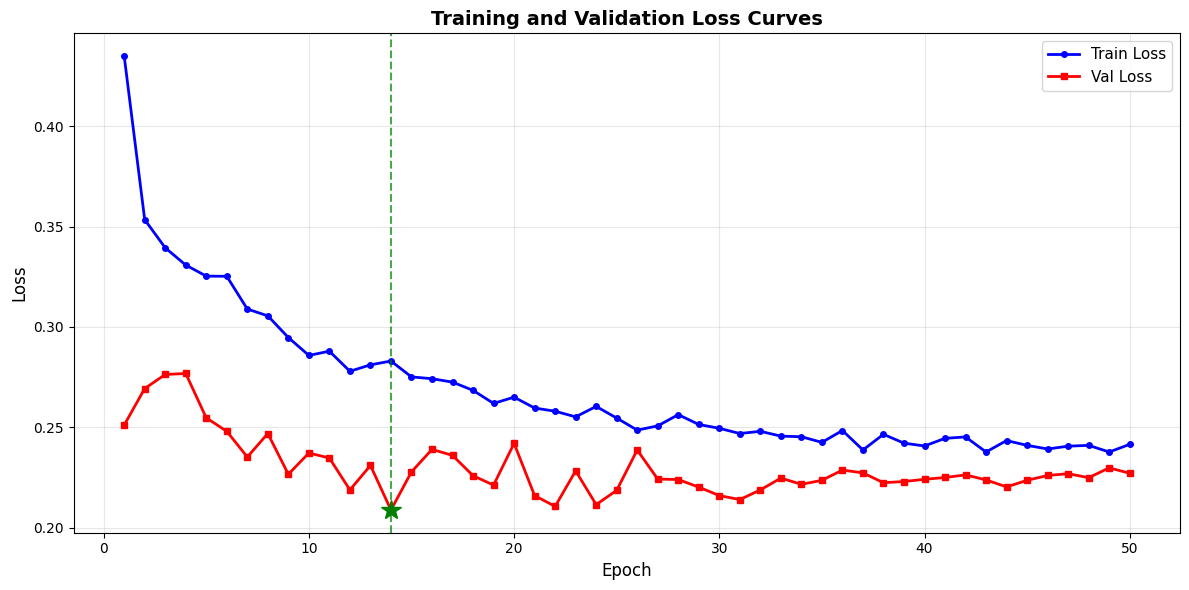


✓ Best validation loss: 0.2088 at epoch 14
✓ Final training loss: 0.2415
✓ Final validation loss: 0.2271


In [ ]:
import matplotlib.pyplot as plt

train_losses = [0.4349, 0.3534, 0.3394, 0.3308, 0.3253, 0.3252, 0.3089, 0.3055, 0.2947, 0.2858, 
                0.2879, 0.2779, 0.2811, 0.2830, 0.2751, 0.2742, 0.2725, 0.2684, 0.2619, 0.2650, 
                0.2596, 0.2580, 0.2552, 0.2604, 0.2546, 0.2486, 0.2507, 0.2563, 0.2514, 0.2495, 
                0.2469, 0.2480, 0.2456, 0.2453, 0.2425, 0.2484, 0.2387, 0.2465, 0.2421, 0.2407, 
                0.2445, 0.2452, 0.2377, 0.2434, 0.2410, 0.2392, 0.2406, 0.2410, 0.2377, 0.2415]

val_losses = [0.2511, 0.2693, 0.2763, 0.2768, 0.2547, 0.2480, 0.2352, 0.2469, 0.2266, 0.2372, 
              0.2347, 0.2188, 0.2310, 0.2088, 0.2278, 0.2390, 0.2360, 0.2259, 0.2212, 0.2420, 
              0.2160, 0.2106, 0.2283, 0.2115, 0.2186, 0.2387, 0.2242, 0.2240, 0.2202, 0.2160, 
              0.2140, 0.2188, 0.2247, 0.2216, 0.2236, 0.2287, 0.2273, 0.2224, 0.2230, 0.2241, 
              0.2250, 0.2263, 0.2238, 0.2203, 0.2236, 0.2260, 0.2269, 0.2249, 0.2298, 0.2271]

def plot_training_curves(train_losses, val_losses):
    """Plot training and validation loss curves."""
    plt.figure(figsize=(12, 6))
    
    epochs = range(1, len(train_losses) + 1)
    
    plt.plot(epochs, train_losses, 'b-', label='Train Loss', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs, val_losses, 'r-', label='Val Loss', linewidth=2, marker='s', markersize=4)
    
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training and Validation Loss Curves', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    # Find and mark best model
    best_epoch = np.argmin(val_losses) + 1
    best_val_loss = min(val_losses)
    plt.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Model (Epoch {best_epoch})')
    plt.plot(best_epoch, best_val_loss, 'g*', markersize=15)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")
    print(f"✓ Final training loss: {train_losses[-1]:.4f}")
    print(f"✓ Final validation loss: {val_losses[-1]:.4f}")

# Plot the curves
plot_training_curves(train_losses, val_losses)

In [203]:
import torch
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(model, test_loader, device, threshold=0.7):
    model.eval()  # Set model to evaluation mode (disables Dropout/BatchNorm)
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():  # No need to track gradients during testing
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            
            # Get model output
            outputs = model(inputs).squeeze()
            #raw_outputs = model(inputs).squeeze()
            #outputs = torch.sigmoid(raw_outputs).squeeze()  # Apply sigmoid to get probabilities
            # Store raw probabilities for AUC
            all_probs.extend(outputs.cpu().numpy())
            
            # Apply threshold to get binary classes
            preds = (outputs > threshold).float()
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# --- EXECUTION ---
# Load the best weights saved during training
model.load_state_dict(torch.load('best_multibranch_model_quat.pth'))

y_true, y_pred, y_probs = evaluate_model(model, test_loader, device, threshold=0.3)

In [204]:
print("\n" + "="*30)
print("   FINAL TEST RESULTS")
print("="*30)

# 1. Classification Report
print(classification_report(y_true, y_pred, target_names=['Normal', 'FoG']))

# 2. AUC Score (measures how well the model separates the two classes)
auc = roc_auc_score(y_true, y_probs)
print(f"Test AUC-ROC: {auc:.4f}")

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)


   FINAL TEST RESULTS
              precision    recall  f1-score   support

      Normal       0.92      0.92      0.92      1392
         FoG       0.72      0.73      0.72       390

    accuracy                           0.88      1782
   macro avg       0.82      0.82      0.82      1782
weighted avg       0.88      0.88      0.88      1782

Test AUC-ROC: 0.9117

Confusion Matrix:
[[1281  111]
 [ 106  284]]


In [ ]:
print("Threshold Optimization:")
print("Thresh | Precision | Recall | F1-Score")
print("-" * 40)

# Loop through thresholds from 0.3 to 0.8
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    # Apply the threshold to the raw probabilities
    y_pred_adjusted = (y_probs > t).astype(int)
    
    p = precision_score(y_true, y_pred_adjusted)
    r = recall_score(y_true, y_pred_adjusted)
    f = f1_score(y_true, y_pred_adjusted)
    
    print(f"  {t:.1f}  |   {p:.2f}    |  {r:.2f}  |   {f:.2f}")

Threshold Optimization:
Thresh | Precision | Recall | F1-Score
----------------------------------------
  0.3  |   0.72    |  0.73  |   0.72
  0.4  |   0.77    |  0.61  |   0.68
  0.5  |   0.80    |  0.52  |   0.63
  0.6  |   0.83    |  0.45  |   0.58
  0.7  |   0.84    |  0.35  |   0.49
  0.8  |   0.86    |  0.18  |   0.29


In [55]:
num_normal = (y_train == 0).sum()
num_fog = (y_train == 1).sum()

# Calculate the weight: How much more we should care about FoG
weight_ratio = num_normal / num_fog 
print(f"FoG Weight Penalty: {weight_ratio:.2f}")
pos_weight = torch.tensor([weight_ratio], dtype=torch.float32).to(device)

FoG Weight Penalty: 3.12


## PCA visualization of the learned features

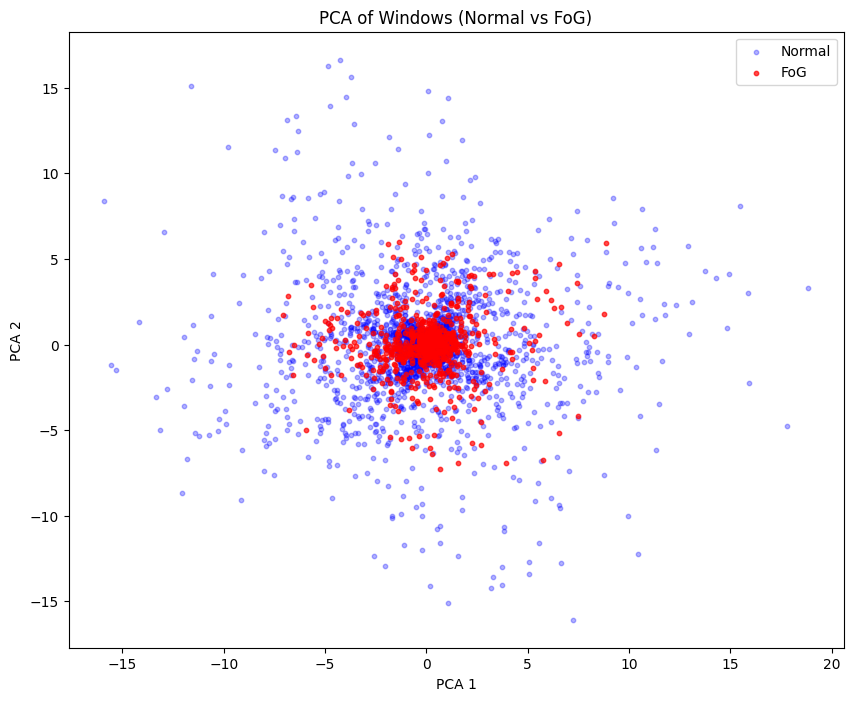

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


X_train_flat = X_train.reshape(X_train.shape[0], -1)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_flat)

plt.figure(figsize=(10, 8))

plt.scatter(X_pca[y_train == 0, 0], X_pca[y_train == 0, 1], 
            c='blue', label='Normal', alpha=0.3, s=10)

plt.scatter(X_pca[y_train == 1, 0], X_pca[y_train == 1, 1], 
            c='red', label='FoG', alpha=0.7, s=10)

plt.title('PCA of Windows (Normal vs FoG)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()

Calcul du t-SNE en cours... (patientez quelques minutes)
Calcul terminé !


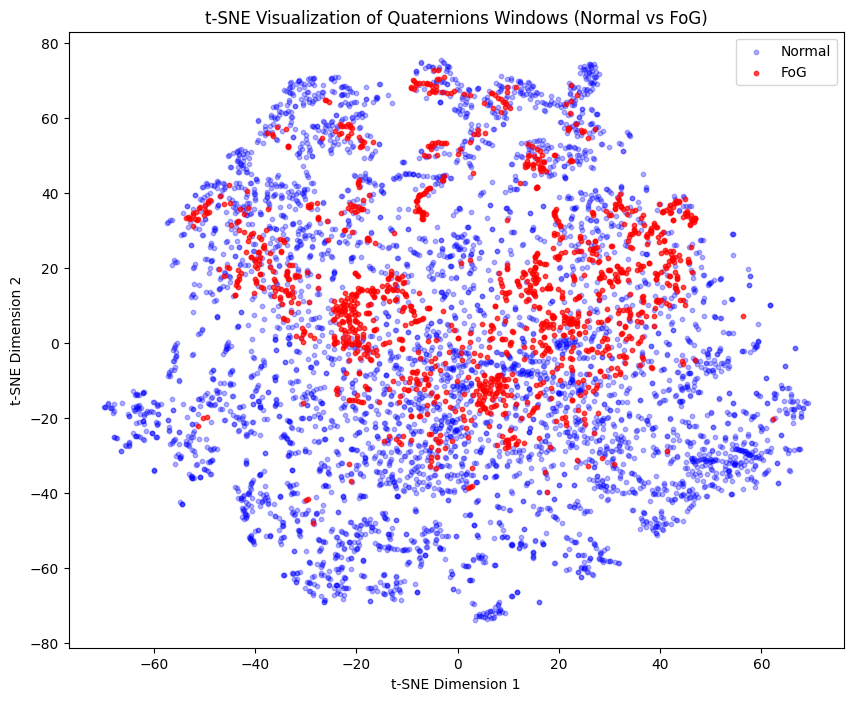

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

X_train_flat = X_train.reshape(X_train.shape[0], -1)


tsne = TSNE(n_components=2, perplexity=30, random_state=42)

X_tsne = tsne.fit_transform(X_train_flat)

plt.figure(figsize=(10, 8))

plt.scatter(X_tsne[y_train == 0, 0], X_tsne[y_train == 0, 1], 
            c='blue', label='Normal', alpha=0.3, s=10)

plt.scatter(X_tsne[y_train == 1, 0], X_tsne[y_train == 1, 1], 
            c='red', label='FoG', alpha=0.7, s=10)

plt.title('t-SNE Visualization of Quaternions Windows (Normal vs FoG)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.show()

## Per-Subject analysis + class imbalance analysis

In [ ]:
import pandas as pd



df=pd.read_csv('sensor_data_complete.csv') 
repartition = df.groupby(['subjectID', 'fog']).size().unstack(fill_value=0)

repartition.columns = ['Normal (0)', 'FoG (1)']

repartition['% de FoG'] = (repartition['FoG (1)'] / (repartition['Normal (0)'] + repartition['FoG (1)'])) * 100

print("--- Fog repartition per subject ---")
print(repartition.round(2)) 

--- Fog repartition per subject ---
           Normal (0)  FoG (1)  % de FoG
subjectID                               
1               10906    10583     49.25
2               16086    18129     52.99
3               15044     5226     25.78
4               18728      642      3.31
5                9091      354      3.75
6                8703        0      0.00
7               18734        0      0.00
8                7442        0      0.00
9               13796     2435     15.00
10              16020        0      0.00
11              10405     3450     24.90
12              14185     3102     17.94
13               9822     1178     10.71
14              10684        0      0.00
15              11227     3620     24.38
16              13268       78      0.58
17               7904      333      4.04
18              16093        0      0.00
19              12002     9926     45.27
20              11558     1032      8.20
21               8178     2814     25.60
22               4824

In [ ]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

eval_subjects = [17, 18, 19, 20, 21, 22]
threshold = 0.3

model.eval()

for subject in eval_subjects:
    print("\n" + "=" * 45)
    print(f"      EVALUATION FOR THE SUBJECT {subject}")
    print("=" * 45)

    X_subj, y_subj = segment_data(df_quat, [subject], w=2, o=0.75)

    if len(X_subj) == 0:
        print("Aucune fenetre pour ce sujet.")
        continue

    subj_dataset = FogDataset(X_subj, y_subj)
    subj_loader = torch.utils.data.DataLoader(subj_dataset, batch_size=256, shuffle=False)

    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for inputs, labels in subj_loader:
            inputs = inputs.to(device)
            outputs = model(inputs).squeeze()

            if outputs.dim() == 0:
                outputs = outputs.unsqueeze(0)

            probs = outputs
            preds = (probs > threshold).int().cpu().numpy()

            y_pred_all.extend(preds.tolist())
            y_true_all.extend(labels.cpu().numpy().astype(int).tolist())

    y_true_all = np.array(y_true_all, dtype=int)
    y_pred_all = np.array(y_pred_all, dtype=int)

    print("\nClassification Report:")
    print(
        classification_report(
            y_true_all,
            y_pred_all,
            labels=[0, 1],
            target_names=['Normal', 'FoG'],
            zero_division=0
        )
    )

    print("Matrice de confusion:")
    print(confusion_matrix(y_true_all, y_pred_all, labels=[0, 1]))


      EVALUATION FOR THE SUBJECT 17

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        30
         FoG       0.00      0.00      0.00         0

    accuracy                           1.00        30
   macro avg       0.50      0.50      0.50        30
weighted avg       1.00      1.00      1.00        30

Matrice de confusion:
[[30  0]
 [ 0  0]]

      EVALUATION FOR THE SUBJECT 18

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       457
         FoG       0.00      0.00      0.00         0

    accuracy                           0.98       457
   macro avg       0.50      0.49      0.50       457
weighted avg       1.00      0.98      0.99       457

Matrice de confusion:
[[450   7]
 [  0   0]]

      EVALUATION FOR THE SUBJECT 19

Classification Report:
              precision    recall  f1-score   support

      Normal       0.8


    PERFORMANCE METRICS PER SUBJECT
 Subject  Accuracy  Precision   Recall  F1-Score  Samples
      17  1.000000   0.000000 0.000000  0.000000       30
      18  0.984683   0.000000 0.000000  0.000000      457
      19  0.800550   0.772861 0.793939  0.783259      727
      20  0.877404   0.257143 0.264706  0.260870      416
      21  0.903226   1.000000 0.454545  0.625000       62
      22  0.911111   0.888889 0.533333  0.666667       90


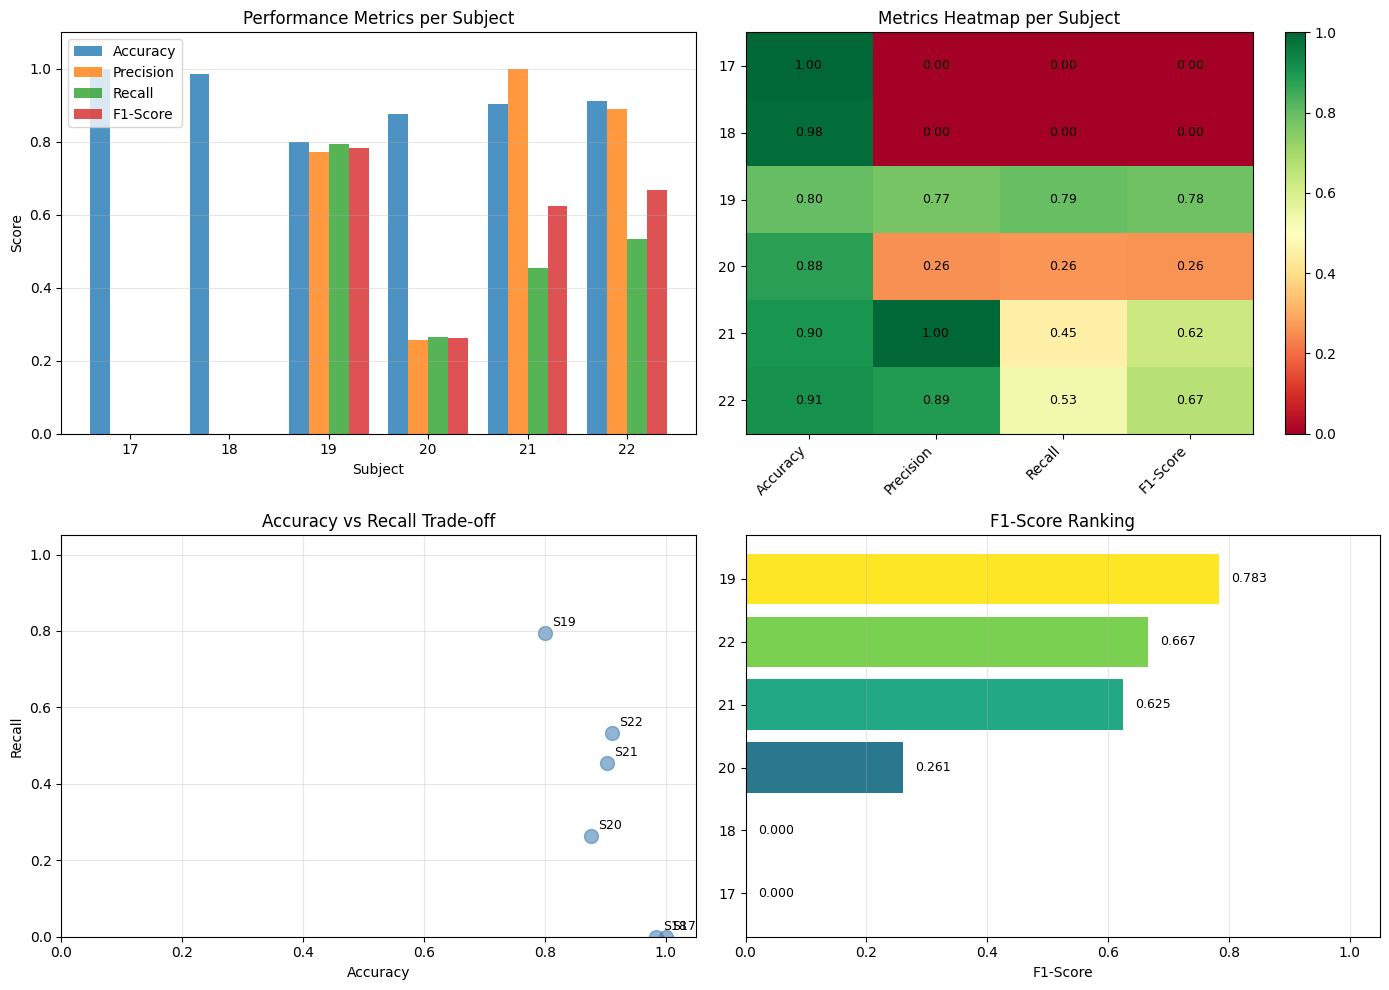


    SUMMARY STATISTICS
Average Accuracy:  0.9128 (±0.0731)
Average Precision: 0.4865 (±0.4547)
Average Recall:    0.3411 (±0.3141)
Average F1-Score:  0.3893 (±0.3485)


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

eval_subjects = [17, 18, 19, 20, 21, 22]
threshold = 0.3

model.eval()
results_per_subject = []

for subject in eval_subjects:
    X_subj, y_subj = segment_data(df_quat, [subject], w=2, o=0.75)
    
    if len(X_subj) == 0:
        print(f"⚠ Aucune données pour le sujet {subject}")
        continue
    
    # Prédiction
    subj_dataset = FogDataset(X_subj, y_subj)
    subj_loader = torch.utils.data.DataLoader(subj_dataset, batch_size=256, shuffle=False)
    
    y_true_all = []
    y_pred_all = []
    
    with torch.no_grad():
        for inputs, labels in subj_loader:
            inputs = inputs.to(device)
            outputs = model(inputs).squeeze()
            
            if outputs.dim() == 0:
                outputs = outputs.unsqueeze(0)
            
            preds = (outputs > threshold).int().cpu().numpy()
            y_pred_all.extend(preds.tolist())
            y_true_all.extend(labels.cpu().numpy().astype(int).tolist())
    
    y_true_all = np.array(y_true_all, dtype=int)
    y_pred_all = np.array(y_pred_all, dtype=int)
    
    acc = accuracy_score(y_true_all, y_pred_all)
    prec = precision_score(y_true_all, y_pred_all, zero_division=0)
    rec = recall_score(y_true_all, y_pred_all, zero_division=0)
    f1 = f1_score(y_true_all, y_pred_all, zero_division=0)
    
    # Store results
    results_per_subject.append({
        'Subject': subject,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Samples': len(y_true_all)
    })

results_df = pd.DataFrame(results_per_subject)

print("\n" + "="*60)
print("    PERFORMANCE METRICS PER SUBJECT")
print("="*60)
print(results_df.to_string(index=False))

# === VISUALIZATIONS ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Comparaison de tous les métriques par sujet
ax = axes[0, 0]
subjects = results_df['Subject'].astype(str)
x = np.arange(len(subjects))
width = 0.2

ax.bar(x - 1.5*width, results_df['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x - 0.5*width, results_df['Precision'], width, label='Precision', alpha=0.8)
ax.bar(x + 0.5*width, results_df['Recall'], width, label='Recall', alpha=0.8)
ax.bar(x + 1.5*width, results_df['F1-Score'], width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Subject')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics per Subject')
ax.set_xticks(x)
ax.set_xticklabels(subjects)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])

# 2. Heatmap des métriques
ax = axes[0, 1]
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
heatmap_data = results_df[metrics_cols].values
im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(np.arange(len(metrics_cols)))
ax.set_yticks(np.arange(len(subjects)))
ax.set_xticklabels(metrics_cols, rotation=45, ha='right')
ax.set_yticklabels(subjects)
ax.set_title('Metrics Heatmap per Subject')
for i in range(len(subjects)):
    for j in range(len(metrics_cols)):
        text = ax.text(j, i, f'{heatmap_data[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=9)
plt.colorbar(im, ax=ax)

# 3. Accuracy vs Recall (Trade-off)
ax = axes[1, 0]
ax.scatter(results_df['Accuracy'], results_df['Recall'], s=100, alpha=0.6, color='steelblue')
for i, row in results_df.iterrows():
    ax.annotate(f"S{int(row['Subject'])}", 
               (row['Accuracy'], row['Recall']),
               xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_xlabel('Accuracy')
ax.set_ylabel('Recall')
ax.set_title('Accuracy vs Recall Trade-off')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1.05])
ax.set_ylim([0, 1.05])

# 4. F1-Score ranking
ax = axes[1, 1]
results_sorted = results_df.sort_values('F1-Score', ascending=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(results_sorted)))
bars = ax.barh(results_sorted['Subject'].astype(str), results_sorted['F1-Score'], color=colors)
ax.set_xlabel('F1-Score')
ax.set_title('F1-Score Ranking')
ax.set_xlim([0, 1.05])
for i, (idx, row) in enumerate(results_sorted.iterrows()):
    ax.text(row['F1-Score'] + 0.02, i, f"{row['F1-Score']:.3f}", va='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("    SUMMARY STATISTICS")
print("="*60)
print(f"Average Accuracy:  {results_df['Accuracy'].mean():.4f} (±{results_df['Accuracy'].std():.4f})")
print(f"Average Precision: {results_df['Precision'].mean():.4f} (±{results_df['Precision'].std():.4f})")
print(f"Average Recall:    {results_df['Recall'].mean():.4f} (±{results_df['Recall'].std():.4f})")
print(f"Average F1-Score:  {results_df['F1-Score'].mean():.4f} (±{results_df['F1-Score'].std():.4f})")

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# === INVESTIGATING INTER-SUBJECT VARIABILITY ===
# This analysis reveals what makes some subjects harder than others

eval_subjects = [17, 18, 19, 20, 21, 22]
threshold = 0.3

model.eval()
detailed_results = []

print("\n" + "="*70)
print("  DETAILED PER-SUBJECT ANALYSIS: Understanding Variability Sources")
print("="*70)

for subject in eval_subjects:
    X_subj, y_subj = segment_data(df_quat, [subject], w=2, o=0.75)
    
    if len(X_subj) == 0:
        continue
    
    subj_dataset = FogDataset(X_subj, y_subj)
    subj_loader = torch.utils.data.DataLoader(subj_dataset, batch_size=256, shuffle=False)
    
    y_true_all = []
    y_pred_all = []
    y_probs_all = []
    
    with torch.no_grad():
        for inputs, labels in subj_loader:
            inputs = inputs.to(device)
            outputs = model(inputs).squeeze()
            
            if outputs.dim() == 0:
                outputs = outputs.unsqueeze(0)
            
            y_probs_all.extend(outputs.cpu().numpy())
            preds = (outputs > threshold).int().cpu().numpy()
            y_pred_all.extend(preds.tolist())
            y_true_all.extend(labels.cpu().numpy().astype(int).tolist())
    
    y_true_all = np.array(y_true_all, dtype=int)
    y_pred_all = np.array(y_pred_all, dtype=int)
    y_probs_all = np.array(y_probs_all)
    
    # === DATA CHARACTERISTICS ===
    n_samples = len(y_true_all)
    n_fog = np.sum(y_true_all)
    n_normal = n_samples - n_fog
    fog_prevalence = 100 * n_fog / n_samples
    
    # === CONFUSION MATRIX ===
    cm = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    # === PREDICTION STATISTICS ===
    pred_mean = np.mean(y_probs_all)
    pred_std = np.std(y_probs_all)
    
    # Separate by true label
    pred_normal_mean = np.mean(y_probs_all[y_true_all == 0]) if n_normal > 0 else 0
    pred_fog_mean = np.mean(y_probs_all[y_true_all == 1]) if n_fog > 0 else 0
    pred_normal_std = np.std(y_probs_all[y_true_all == 0]) if n_normal > 0 else 0
    pred_fog_std = np.std(y_probs_all[y_true_all == 1]) if n_fog > 0 else 0
    
    # Separability metric (how well separated are the two classes)
    class_separability = abs(pred_fog_mean - pred_normal_mean) / (max(pred_normal_std, pred_fog_std) + 1e-6)
    
    detailed_results.append({
        'Subject': subject,
        'n_total': n_samples,
        'n_fog': n_fog,
        'n_normal': n_normal,
        'FoG%': fog_prevalence,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'pred_mean': pred_mean,
        'pred_std': pred_std,
        'pred_normal_mean': pred_normal_mean,
        'pred_normal_std': pred_normal_std,
        'pred_fog_mean': pred_fog_mean,
        'pred_fog_std': pred_fog_std,
        'class_sep': class_separability
    })

detail_df = pd.DataFrame(detailed_results)

# === VISUALIZATIONS ===
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Data imbalance per subject
ax1 = fig.add_subplot(gs[0, 0])
width = 0.35
subjects_str = detail_df['Subject'].astype(str)
x = np.arange(len(subjects_str))
ax1.bar(x - width/2, detail_df['n_normal'], width, label='Normal', alpha=0.8, color='steelblue')
ax1.bar(x + width/2, detail_df['n_fog'], width, label='FoG', alpha=0.8, color='crimson')
ax1.set_ylabel('# Samples')
ax1.set_title('Data Distribution per Subject')
ax1.set_xticks(x)
ax1.set_xticklabels(subjects_str)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. FoG Prevalence
ax2 = fig.add_subplot(gs[0, 1])
colors_prev = ['crimson' if x > 50 else 'steelblue' for x in detail_df['FoG%']]
ax2.bar(subjects_str, detail_df['FoG%'], color=colors_prev, alpha=0.7)
ax2.axhline(50, color='gray', linestyle='--', alpha=0.5, label='50% (balanced)')
ax2.set_ylabel('FoG Prevalence (%)')
ax2.set_title('Class Imbalance Severity')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend()

# 3. Prediction separability (how well the model separates the classes)
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(subjects_str, detail_df['class_sep'], color='purple', alpha=0.6)
ax3.set_ylabel('Class Separability')
ax3.set_title('Model\'s Ability to Separate Classes\n(Higher = Easier)')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Confusion Matrix: False Positives vs False Negatives
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(detail_df['FP'], detail_df['FN'], s=200, alpha=0.6, c=detail_df['Subject'], cmap='tab10')
for i, row in detail_df.iterrows():
    ax4.annotate(f"S{int(row['Subject'])}", (row['FP'], row['FN']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax4.set_xlabel('False Positives')
ax4.set_ylabel('False Negatives')
ax4.set_title('Error Types per Subject')
ax4.grid(True, alpha=0.3)

# 5. FP+FN (total errors) vs FoG prevalence
ax5 = fig.add_subplot(gs[1, 1])
total_errors = detail_df['FP'] + detail_df['FN']
ax5.scatter(detail_df['FoG%'], total_errors, s=200, alpha=0.6, c=detail_df['Subject'], cmap='tab10')
for i, row in detail_df.iterrows():
    ax5.annotate(f"S{int(row['Subject'])}", (row['FoG%'], total_errors.iloc[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax5.set_xlabel('FoG Prevalence (%)')
ax5.set_ylabel('Total Errors (FP + FN)')
ax5.set_title('Does Class Imbalance Cause Errors?')
ax5.grid(True, alpha=0.3)

# 6. Prediction overlap (measure of confusability)
ax6 = fig.add_subplot(gs[1, 2])
overlap = []
for i, row in detail_df.iterrows():
    # How much do prediction distributions overlap?
    # Defined as: max(std_normal, std_fog) / distance between means
    overlap_val = max(row['pred_normal_std'], row['pred_fog_std']) / (abs(row['pred_fog_mean'] - row['pred_normal_mean']) + 1e-6)
    overlap.append(overlap_val)
ax6.bar(subjects_str, overlap, color='orange', alpha=0.7)
ax6.set_ylabel('Prediction Overlap')
ax6.set_title('Prediction Distribution Overlap\n(Higher = More Confusing)')
ax6.grid(True, alpha=0.3, axis='y')

# 7. Error breakdown (stacked bar)
ax7 = fig.add_subplot(gs[2, 0])
ax7.bar(subjects_str, detail_df['TP'], label='TP', alpha=0.8, color='green')
ax7.bar(subjects_str, detail_df['FP'], bottom=detail_df['TP'], label='FP', alpha=0.8, color='red')
ax7.bar(subjects_str, detail_df['FN'], bottom=detail_df['TP']+detail_df['FP'], label='FN', alpha=0.8, color='orange')
ax7.bar(subjects_str, detail_df['TN'], bottom=detail_df['TP']+detail_df['FP']+detail_df['FN'], label='TN', alpha=0.8, color='blue')
ax7.set_ylabel('Count')
ax7.set_title('Prediction Breakdown per Subject')
ax7.legend(loc='upper left', ncol=4)
ax7.grid(True, alpha=0.3, axis='y')

# 8. Prediction confidence per true label
ax8 = fig.add_subplot(gs[2, 1])
x_pos = np.arange(len(subjects_str))
width = 0.35
ax8.bar(x_pos - width/2, detail_df['pred_normal_mean'], width, label='Pred for Normal', alpha=0.7, color='steelblue')
ax8.bar(x_pos + width/2, detail_df['pred_fog_mean'], width, label='Pred for FoG', alpha=0.7, color='crimson')
ax8.axhline(threshold, color='black', linestyle='--', alpha=0.5, label=f'Threshold={threshold}')
ax8.set_ylabel('Mean Prediction Value')
ax8.set_title('Model Confidence by True Label')
ax8.set_xticks(x_pos)
ax8.set_xticklabels(subjects_str)
ax8.legend()
ax8.grid(True, alpha=0.3, axis='y')
ax8.set_ylim([0, 1])

# 9. Subjects ranking by difficulty (inverse of separability)
ax9 = fig.add_subplot(gs[2, 2])
difficulty = 1 / (detail_df['class_sep'] + 1e-6)
difficulty_sorted = difficulty.sort_values(ascending=False)
colors_diff = plt.cm.RdYlGn_r(np.linspace(0.3, 0.8, len(difficulty_sorted)))
ax9.barh(difficulty_sorted.index.astype(str), difficulty_sorted.values, color=colors_diff)
ax9.set_xlabel('Difficulty Index')
ax9.set_title('Subject Ranking by Difficulty\n(Higher = Harder to Classify)')
ax9.grid(True, alpha=0.3, axis='x')

plt.suptitle('Inter-Subject Variability Root Cause Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()

# === PRINT DETAILED INSIGHTS ===
print("\n" + "-"*70)
print("KEY FINDINGS:")
print("-"*70)

print("\n Data Characteristics per Subject:")
print(detail_df[['Subject', 'n_total', 'FoG%', 'pred_normal_mean', 'pred_fog_mean', 'class_sep']].to_string(index=False))

print("\n Error Analysis:")
print(detail_df[['Subject', 'TP', 'FP', 'FN', 'TN']].to_string(index=False))

print("\n  Most Problematic Subjects (by total errors):")
total_errors = detail_df['FP'] + detail_df['FN']
problematic = detail_df.copy()
problematic['total_errors'] = total_errors
problematic_sorted = problematic.sort_values('total_errors', ascending=False)
print(problematic_sorted[['Subject', 'total_errors', 'FoG%', 'class_sep']].to_string(index=False))

print("\n Interpretation:")
print("- Subjects with HIGH FoG% AND HIGH errors → Class imbalance problem")
print("- Subjects with LOW class_sep AND HIGH errors → Model can't distinguish classes")
print("- Subjects with HIGH FP → Model over-predicts FoG")
print("- Subjects with HIGH FN → Model under-predicts FoG")

/var/folders/5w/6s16lbnx19g0d7hy__grtsb40000gn/T/ipykernel_85667/108713934.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(subjects_list, rotation=45, ha='right', fontsize=9)


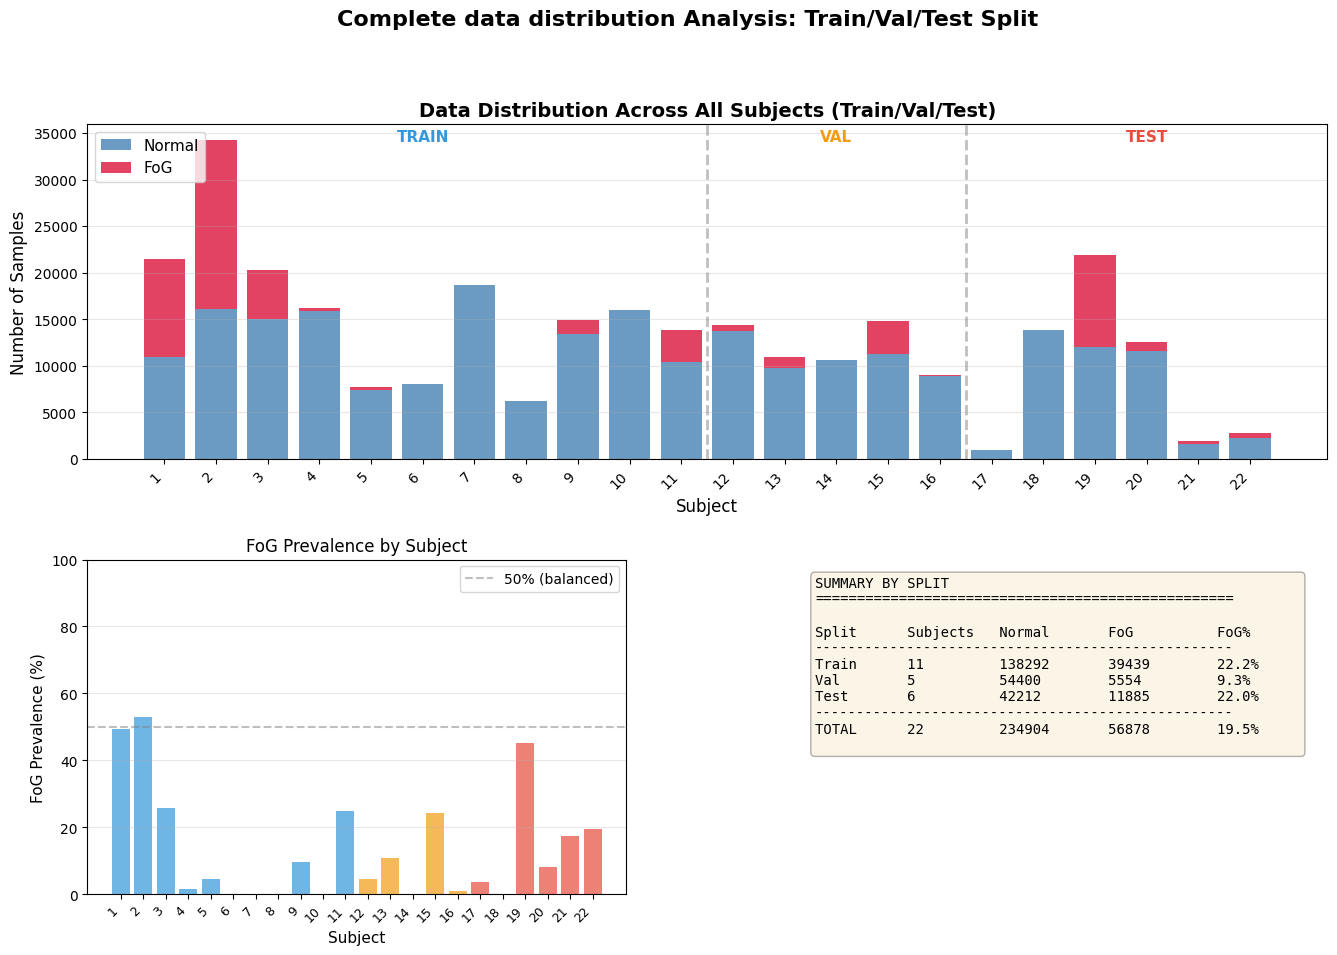


COMPLETE DATA DISTRIBUTION ANALYSIS

📊 Per-Subject Breakdown:
 Subject  Normal   FoG  Total      FoG% Split
       1   10906 10583  21489 49.248453 Train
       2   16086 18129  34215 52.985533 Train
       3   15044  5226  20270 25.781944 Train
       4   15932   264  16196  1.630032 Train
       5    7430   354   7784  4.547790 Train
       6    8072     0   8072  0.000000 Train
       7   18734     0  18734  0.000000 Train
       8    6207     0   6207  0.000000 Train
       9   13456  1433  14889  9.624555 Train
      10   16020     0  16020  0.000000 Train
      11   10405  3450  13855 24.900758 Train
      12   13713   678  14391  4.711278   Val
      13    9822  1178  11000 10.709091   Val
      14   10684     0  10684  0.000000   Val
      15   11227  3620  14847 24.382030   Val
      16    8954    78   9032  0.863596   Val
      17     968    36   1004  3.585657  Test
      18   13812     0  13812  0.000000  Test
      19   12002  9926  21928 45.266326  Test
      20   11558 

In [ ]:
# === DATA DISTRIBUTION ACROSS ALL SUBJECTS ===
# Define subject groups
train_subjects = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
val_subjects = [12, 13, 14, 15, 16]
test_subjects = [17, 18, 19, 20, 21, 22]
all_subjects = train_subjects + val_subjects + test_subjects

# Load the quaternion data
df_q = pd.read_csv('sensor_data_quaternions.csv')

# Map subject ID to split
subject_split = {}
for s in train_subjects:
    subject_split[s] = 'Train'
for s in val_subjects:
    subject_split[s] = 'Val'
for s in test_subjects:
    subject_split[s] = 'Test'

df_q['split'] = df_q['subjectID'].map(subject_split)

# Count FoG vs Normal per subject
distribution_data = []
for subject in all_subjects:
    subject_data = df_q[df_q['subjectID'] == subject]
    
    if len(subject_data) == 0:
        continue
    
    n_normal = (subject_data['fog'] == 0).sum()
    n_fog = (subject_data['fog'] == 1).sum()
    n_total = len(subject_data)
    fog_pct = 100 * n_fog / n_total if n_total > 0 else 0
    split = subject_split[subject]
    
    distribution_data.append({
        'Subject': subject,
        'Normal': n_normal,
        'FoG': n_fog,
        'Total': n_total,
        'FoG%': fog_pct,
        'Split': split
    })

dist_df = pd.DataFrame(distribution_data).sort_values('Subject')

# === VISUALIZATIONS ===
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# 1. Stacked bar chart: All subjects with Normal/FoG distribution
ax1 = fig.add_subplot(gs[0, :])
subjects_list = dist_df['Subject'].astype(str)
x_pos = np.arange(len(subjects_list))

# Color-code by split
colors_split = []
for split in dist_df['Split']:
    if split == 'Train':
        colors_split.append('#3498db')  # Blue
    elif split == 'Val':
        colors_split.append('#f39c12')  # Orange
    else:
        colors_split.append('#e74c3c')  # Red

# Stacked bar
ax1.bar(x_pos, dist_df['Normal'], label='Normal', color='steelblue', alpha=0.8)
ax1.bar(x_pos, dist_df['FoG'], bottom=dist_df['Normal'], label='FoG', color='crimson', alpha=0.8)

# Add vertical lines between splits
ax1.axvline(len(train_subjects) - 0.5, color='gray', linestyle='--', linewidth=2, alpha=0.5)
ax1.axvline(len(train_subjects) + len(val_subjects) - 0.5, color='gray', linestyle='--', linewidth=2, alpha=0.5)

# Labels and formatting
ax1.set_xlabel('Subject', fontsize=12)
ax1.set_ylabel('Number of Samples', fontsize=12)
ax1.set_title('Data Distribution Across All Subjects (Train/Val/Test)', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(subjects_list, rotation=45, ha='right')
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')

# Add split labels on top
ax1.text(len(train_subjects)//2, ax1.get_ylim()[1]*0.95, 'TRAIN', 
         ha='center', fontsize=11, fontweight='bold', color='#3498db')
ax1.text(len(train_subjects) + len(val_subjects)//2, ax1.get_ylim()[1]*0.95, 'VAL', 
         ha='center', fontsize=11, fontweight='bold', color='#f39c12')
ax1.text(len(train_subjects) + len(val_subjects) + len(test_subjects)//2, ax1.get_ylim()[1]*0.95, 'TEST', 
         ha='center', fontsize=11, fontweight='bold', color='#e74c3c')

# 2. FoG Prevalence (%) per subject
ax2 = fig.add_subplot(gs[1, 0])
subject_colors = []
for split in dist_df['Split']:
    if split == 'Train':
        subject_colors.append('#3498db')
    elif split == 'Val':
        subject_colors.append('#f39c12')
    else:
        subject_colors.append('#e74c3c')

bars = ax2.bar(subjects_list, dist_df['FoG%'], color=subject_colors, alpha=0.7)
ax2.axhline(50, color='gray', linestyle='--', alpha=0.5, label='50% (balanced)')
ax2.set_xlabel('Subject', fontsize=11)
ax2.set_ylabel('FoG Prevalence (%)', fontsize=11)
ax2.set_title('FoG Prevalence by Subject')
ax2.set_xticklabels(subjects_list, rotation=45, ha='right', fontsize=9)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim([0, 100])

# 3. Summary by split
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')

summary_by_split = []
for split in ['Train', 'Val', 'Test']:
    split_data = dist_df[dist_df['Split'] == split]
    
    total_normal = split_data['Normal'].sum()
    total_fog = split_data['FoG'].sum()
    total_all = split_data['Total'].sum()
    fog_pct_overall = 100 * total_fog / total_all if total_all > 0 else 0
    n_subjects = len(split_data)
    
    summary_by_split.append({
        'Split': split,
        'Subjects': n_subjects,
        'Normal': total_normal,
        'FoG': total_fog,
        'Total': total_all,
        'FoG%': fog_pct_overall
    })

summary_df = pd.DataFrame(summary_by_split)

# Create table text
table_text = "SUMMARY BY SPLIT\n" + "="*50 + "\n\n"
table_text += f"{'Split':<10} {'Subjects':<10} {'Normal':<12} {'FoG':<12} {'FoG%':<10}\n"
table_text += "-"*50 + "\n"

for _, row in summary_df.iterrows():
    table_text += f"{row['Split']:<10} {int(row['Subjects']):<10} {int(row['Normal']):<12} {int(row['FoG']):<12} {row['FoG%']:.1f}%\n"

table_text += "-"*50 + "\n"
total_row = summary_df.sum(numeric_only=True)
total_normal = int(total_row['Normal'])
total_fog = int(total_row['FoG'])
total_all = int(total_row['Total'])
total_fog_pct = 100 * total_fog / total_all
table_text += f"{'TOTAL':<10} {22:<10} {total_normal:<12} {total_fog:<12} {total_fog_pct:.1f}%\n"

ax3.text(0.05, 0.95, table_text, transform=ax3.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Complete data distribution Analysis: Train/Val/Test Split', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

# === PRINT DETAILED STATISTICS ===
print("\n" + "="*70)
print("COMPLETE DATA DISTRIBUTION ANALYSIS")
print("="*70)

print("\n Per-Subject Breakdown:")
print(dist_df[['Subject', 'Normal', 'FoG', 'Total', 'FoG%', 'Split']].to_string(index=False))

print("\n" + "-"*70)
print("SUMMARY STATISTICS BY SPLIT:")
print("-"*70)
print(summary_df.to_string(index=False))

print("\n" + "-"*70)
print("KEY INSIGHTS:")
print("-"*70)

# Find most imbalanced subjects
most_imbalanced = dist_df.nlargest(3, 'FoG%')[['Subject', 'FoG%', 'Split']]
print(f"\n Most Imbalanced Subjects (Highest FoG%):")
for _, row in most_imbalanced.iterrows():
    print(f"   Subject {int(row['Subject'])}: {row['FoG%']:.1f}% FoG ({row['Split']})")

# Find most balanced subjects
most_balanced = dist_df.loc[dist_df['FoG%'].between(40, 60), ['Subject', 'FoG%', 'Split']]
if len(most_balanced) > 0:
    print(f"\n Most Balanced Subjects (40-60% FoG):")
    for _, row in most_balanced.iterrows():
        print(f"   Subject {int(row['Subject'])}: {row['FoG%']:.1f}% FoG ({row['Split']})")
else:
    print(f"\n No subjects in perfect 40-60% range")

# Class balance per split
print(f"\n📈 Overall Class Balance:")
for _, row in summary_df.iterrows():
    balance_status = "✓ Well-balanced" if 40 <= row['FoG%'] <= 60 else "⚠ Imbalanced"
    print(f"   {row['Split']}: {row['FoG%']:.1f}% FoG {balance_status}")

## Specific subject analysis

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

subject_to_investigate = 17 
X_subj, y_subj = segment_data(df_quat, [subject_to_investigate], w=2, o=0.75)

if len(X_subj) == 0:
    print("Aucune donnée pour ce sujet.")
else:
    # --- 2. LE BON PIPELINE DE DONNÉES (Celui qui marche !) ---
    subj_dataset = FogDataset(X_subj, y_subj)
    subj_loader = torch.utils.data.DataLoader(subj_dataset, batch_size=256, shuffle=False)

    y_true_all = []
    probs_all = []

    model.eval()
    with torch.no_grad():
        for inputs, labels in subj_loader:
            inputs = inputs.to(device)
            outputs = model(inputs).squeeze()

            # Sécurité pour le cas où batch_size = 1
            if outputs.dim() == 0:
                outputs = outputs.unsqueeze(0)

            # On récupère les probabilités pures
            probs = outputs.cpu().numpy()
            
            probs_all.extend(probs.tolist())
            y_true_all.extend(labels.cpu().numpy().astype(int).tolist())

    probs_all = np.array(probs_all)
    y_true_all = np.array(y_true_all)

    # --- 3. GRAPHIQUE 1 : L'HISTOGRAMME DES PROBABILITÉS ---
    plt.figure(figsize=(10, 5))
    
    # Masques pour séparer le Vrai Normal du Vrai FoG
    mask_normal = (y_true_all == 0)
    mask_fog = (y_true_all == 1)

    plt.hist(probs_all[mask_normal], bins=25, alpha=0.5, color='blue', label='Vrai Normal')
    
    # On n'affiche les FoG que s'il y en a pour ce patient
    if np.sum(mask_fog) > 0:
        plt.hist(probs_all[mask_fog], bins=25, alpha=0.7, color='red', label='Vrai FoG')

    plt.axvline(x=0.5, color='black', linestyle='--', label='Seuil (Threshold = 0.5)')
    plt.title(f'Distribution Réelle des Probabilités (Sujet {subject_to_investigate})')
    plt.xlabel('Probabilité prédite de FoG')
    plt.ylabel('Nombre de fenêtres')
    plt.legend()
    plt.xlim(0, 1) # On force l'axe X de 0 à 1 pour bien voir les pourcentages
    plt.show()

    # --- 4. GRAPHIQUE 2 : VISUALISATION DU SIGNAL (SI FoG EXISTE) ---
    if np.sum(mask_fog) > 0:
        idx_fog = np.where(mask_fog)[0][0]       # Premier FoG
        idx_normal = np.where(mask_normal)[0][0] # Premier Normal

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
        canal_a_afficher = 1 # Cheville gauche Q0 par exemple

        ax1.plot(X_subj[idx_normal, canal_a_afficher, :], color='blue')
        ax1.set_title(f"Signal NORMAL - Probabilité : {probs_all[idx_normal]:.2f}")
        ax1.set_xlabel("Temps (échantillons)")

        ax2.plot(X_subj[idx_fog, canal_a_afficher, :], color='red')
        ax2.set_title(f"Signal FoG - Probabilité : {probs_all[idx_fog]:.2f}")
        ax2.set_xlabel("Temps (échantillons)")

        plt.tight_layout()
        plt.show()
    else:
        print(f"Impossible de tracer le signal rouge : le Sujet {subject_to_investigate} n'a fait aucun FoG.")

# Fog severity distribution across all subjects

Comptes fog_severity par patient:
fog_severity      0     1     2      3
subjectID                             
1             10906   150     0  10433
2             16086     0  1536  16593
3             15044     0   714   4512
4             18728   642     0      0
5              9091     0     0    354
6              8703     0     0      0
7             18734     0     0      0
8              7442     0     0      0
9             13796  2051   174    210
10            16020     0     0      0
11            10405     0  1404   2046
12            14185  1062    60   1980
13             9822   300   878      0
14            10684     0     0      0
15            11227     0  3620      0
16            13268     0    78      0
17             7904   333     0      0
18            16093     0     0      0
19            12002     0  2083   7843
20            11558   354   678      0
21             8178  1104  1326    384
22             4824     0  1425      0

Pourcentages fog_severity par

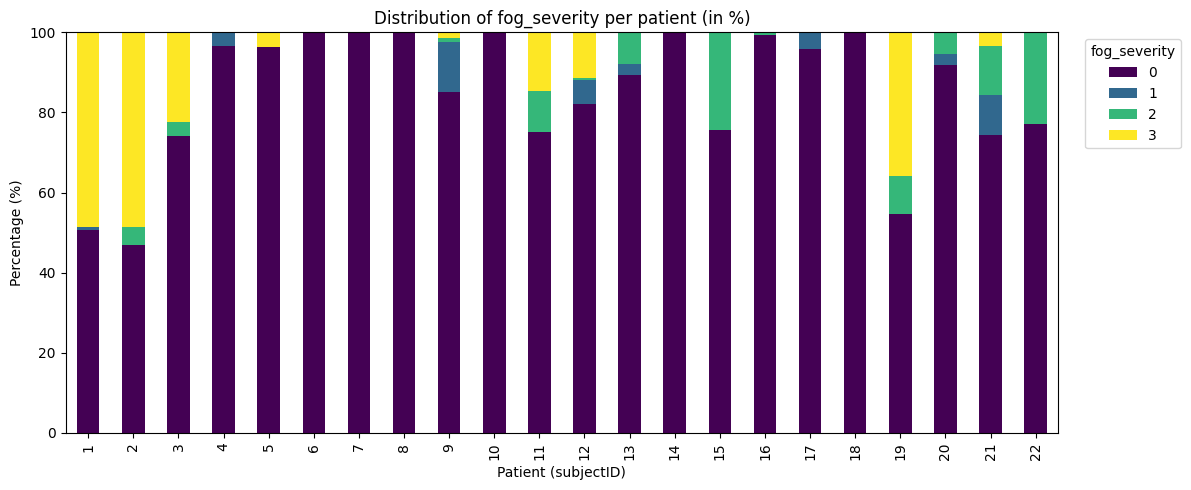

In [ ]:


df_raw = pd.read_csv('sensor_data.csv')

required_cols = {'subjectID', 'fog_severity'}
missing = required_cols - set(df_raw.columns)
if missing:
    raise ValueError(f"Colonnes manquantes dans sensor_data.csv: {missing}")

df_sev = df_raw[['subjectID', 'fog_severity']].dropna().copy()
df_sev['subjectID'] = df_sev['subjectID'].astype(int)

severity_counts = pd.crosstab(df_sev['subjectID'], df_sev['fog_severity'])
severity_counts = severity_counts.sort_index()

severity_pct = severity_counts.div(severity_counts.sum(axis=1), axis=0) * 100

print('Comptes fog_severity par patient:')
print(severity_counts)
print('\nPourcentages fog_severity par patient (%):')
print(severity_pct.round(2))

ax = severity_pct.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='viridis')
ax.set_title('Distribution of fog_severity per patient (in %)')
ax.set_xlabel('Patient (subjectID)')
ax.set_ylabel('Percentage (%)')
ax.legend(title='fog_severity', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Fichier 'sensor_data.csv' chargé avec succès.
--- Comptes de fog_severity par activité ---
fog_severity       0     1      2      3
activity                                
0               5197     0      0      0
1             120628   156    786   3343
2              19590     0      0      0
3              46421     0     90   1295
4               9924     0      0      0
5               7899    36      0     42
6              22480  2879   2349  19084
7              32561  2925  10751  20591

--- Pourcentages de fog_severity par activité (%) ---
fog_severity       0     1      2      3
activity                                
0             100.00  0.00   0.00   0.00
1              96.57  0.12   0.63   2.68
2             100.00  0.00   0.00   0.00
3              97.10  0.00   0.19   2.71
4             100.00  0.00   0.00   0.00
5              99.02  0.45   0.00   0.53
6              48.04  6.15   5.02  40.78
7              48.72  4.38  16.09  30.81


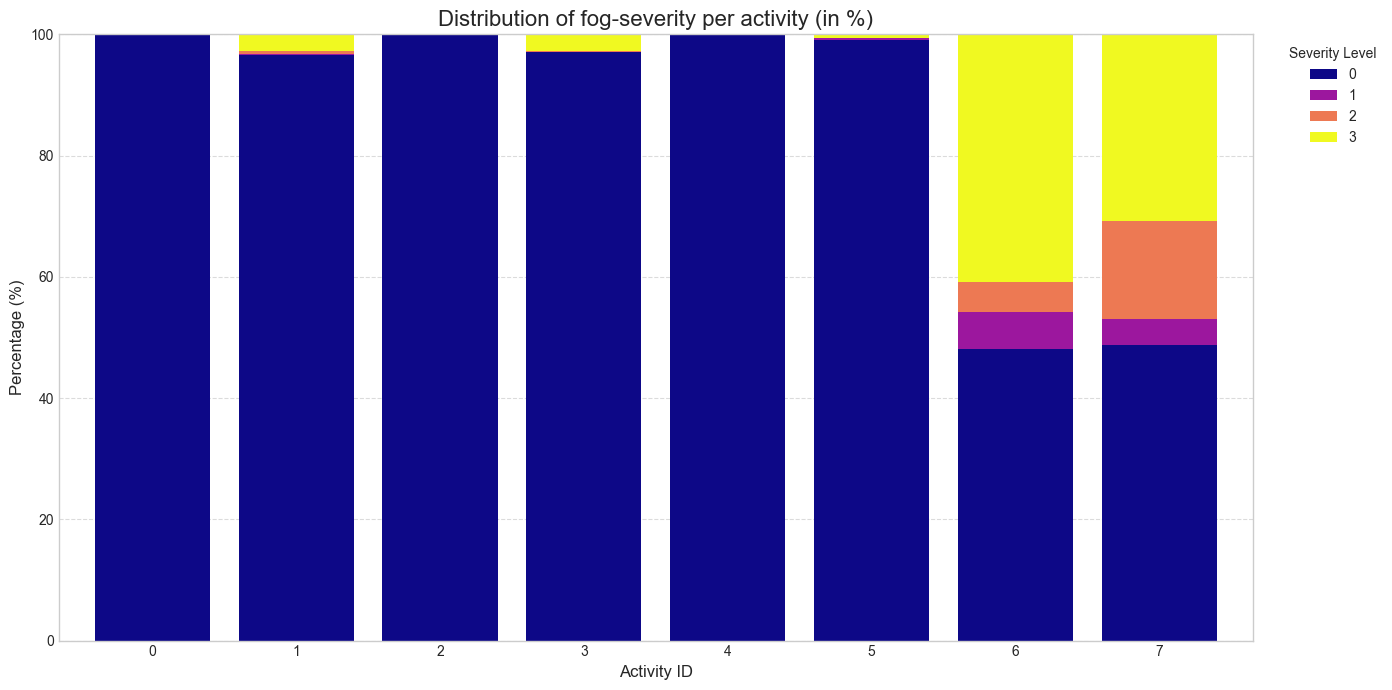

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    df_raw = pd.read_csv('sensor_data.csv')
    print("Fichier 'sensor_data.csv' chargé avec succès.")
except FileNotFoundError:
    print("Erreur : Le fichier 'sensor_data.csv' est introuvable.")
    df_raw = None

if df_raw is not None:
    required_cols = {'activity', 'fog_severity'}
    if not required_cols.issubset(df_raw.columns):
        raise ValueError(f"Colonnes manquantes dans sensor_data.csv: {required_cols - set(df_raw.columns)}")

    df_sev_act = df_raw[['activity', 'fog_severity']].dropna().copy()
    df_sev_act['activity'] = df_sev_act['activity'].astype(int)

    severity_counts_act = pd.crosstab(df_sev_act['activity'], df_sev_act['fog_severity'])
    severity_counts_act = severity_counts_act.sort_index()

 
    severity_pct_act = severity_counts_act.div(severity_counts_act.sum(axis=1), axis=0) * 100

    print('--- Comptes de fog_severity par activité ---')
    print(severity_counts_act)
    print('\n--- Pourcentages de fog_severity par activité (%) ---')
    print(severity_pct_act.round(2))

    ax = severity_pct_act.plot(
        kind='bar', 
        stacked=True, 
        figsize=(14, 7), 
        colormap='plasma',
        width=0.8
    )
    
    ax.set_title('Distribution of fog-severity per activity (in %)', fontsize=16)
    ax.set_xlabel('Activity ID', fontsize=12)
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.legend(title='Severity Level', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=0) # Garder les labels d'activité à l'horizontale
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    ax.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

Fichier 'sensor_data.csv' chargé avec succès.


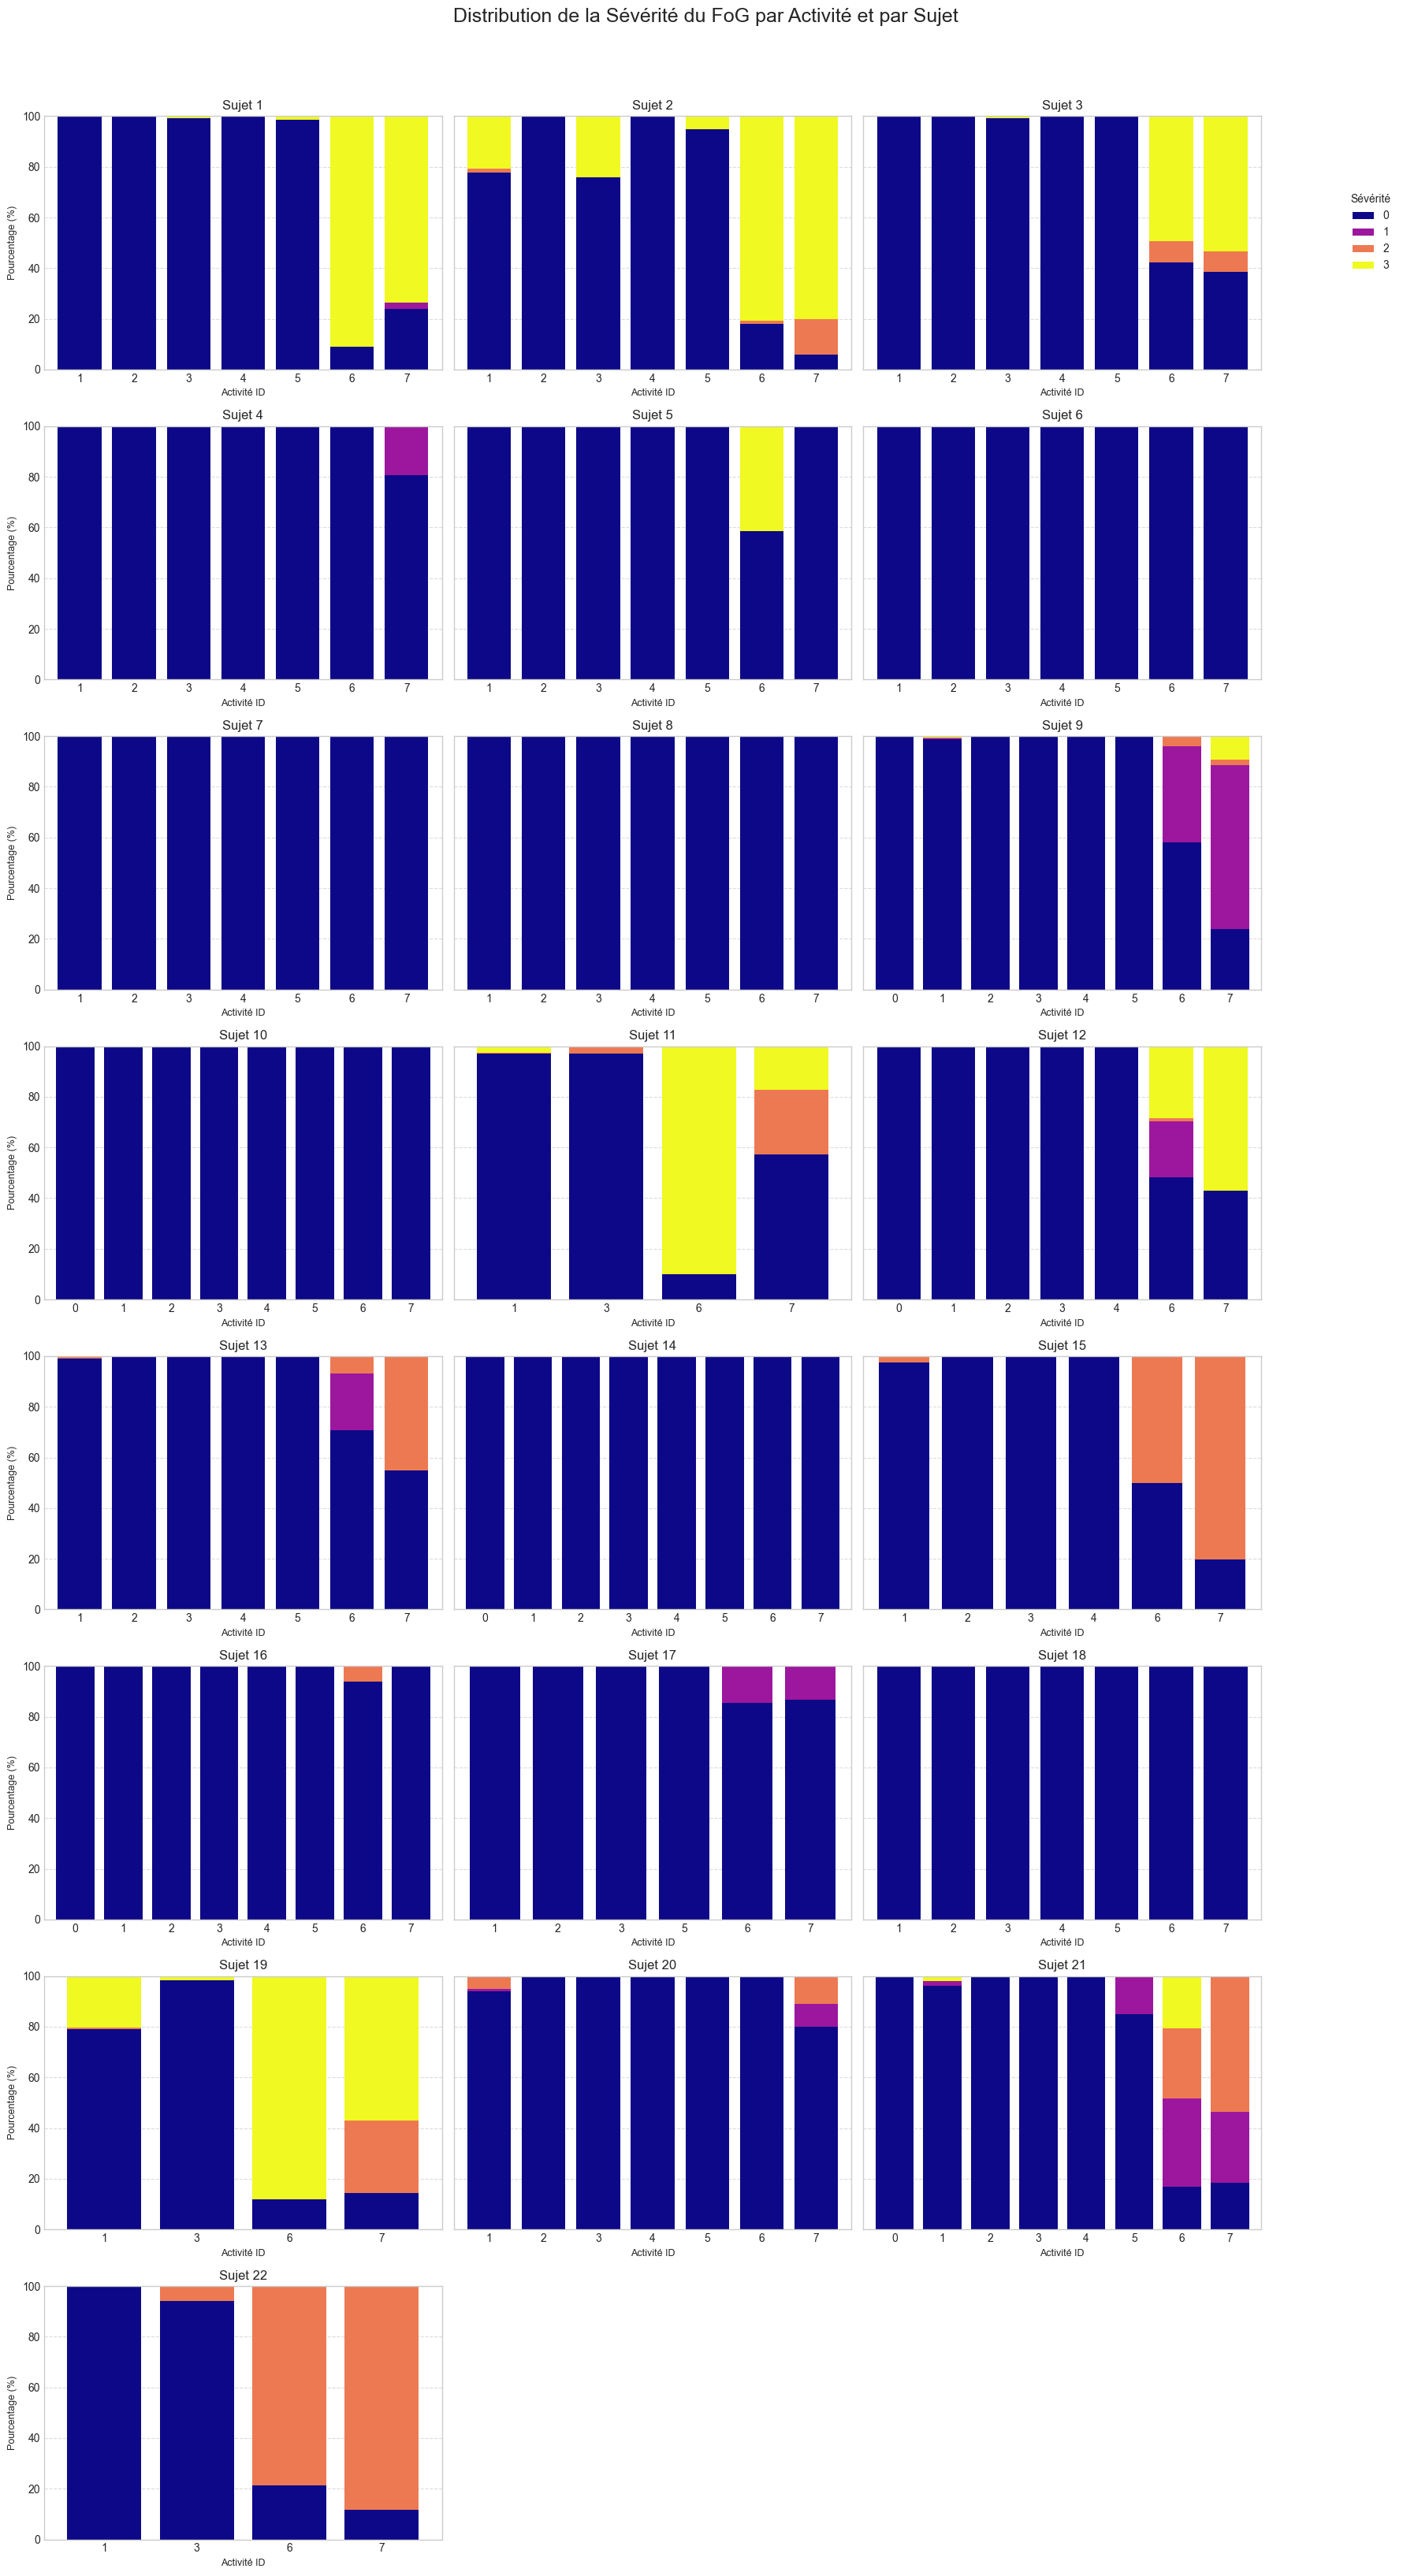

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math

try:
    df_raw = pd.read_csv('sensor_data.csv')
    print("Fichier 'sensor_data.csv' chargé avec succès.")
except FileNotFoundError:
    print("Erreur : Le fichier 'sensor_data.csv' est introuvable.")
    df_raw = None

if df_raw is not None:
    required_cols = {'subjectID', 'activity', 'fog_severity'}
    if not required_cols.issubset(df_raw.columns):
        raise ValueError(f"Colonnes manquantes : {required_cols - set(df_raw.columns)}")

    df_detail = df_raw[list(required_cols)].dropna().copy()
    df_detail[['subjectID', 'activity', 'fog_severity']] = df_detail[['subjectID', 'activity', 'fog_severity']].astype(int)

    counts = df_detail.groupby(['subjectID', 'activity', 'fog_severity']).size().unstack(fill_value=0)
    
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    
    
    subjects = sorted(percentages.index.get_level_values('subjectID').unique())
    n_subjects = len(subjects)
    
    n_cols = 3
    n_rows = math.ceil(n_subjects / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4), sharex=False, sharey=True)
    axes = axes.flatten()

    for i, subject_id in enumerate(subjects):
        ax = axes[i]
        
        subject_data = percentages.loc[subject_id]
        
        if not subject_data.empty:
            subject_data.plot(
                kind='bar',
                stacked=True,
                ax=ax,
                colormap='plasma',
                width=0.8
            )
        
        ax.set_title(f'Sujet {subject_id}', fontsize=12)
        ax.set_xlabel('Activité ID', fontsize=9)
        ax.set_ylabel('Pourcentage (%)', fontsize=9)
        ax.tick_params(axis='x', rotation=0)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.set_ylim(0, 100)
        ax.get_legend().remove() # Enlever les légendes individuelles

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, title='Sévérité', loc='upper right', bbox_to_anchor=(0.99, 0.95))

    fig.suptitle('Distribution de la Sévérité du FoG par Activité et par Sujet', fontsize=18, y=1.02)
    plt.tight_layout(rect=[0, 0, 0.9, 1]) # Ajuster pour laisser de la place à la légende
    plt.show()


Moyenne des quaternions par patient:
           ankleL_q0  ankleL_q1  ankleL_q2  ankleL_q3  ankleR_q0  ankleR_q1  \
subjectID                                                                     
1            -0.1266    -0.2151    -0.1696     0.1929    -0.3175     0.1054   
2             0.0279    -0.1067     0.0284     0.1199    -0.0899    -0.1266   
3            -0.0585    -0.0640    -0.0665     0.0636    -0.0683     0.1038   
4             0.2742    -0.0349     0.2509     0.0712     0.2539    -0.1495   
5             0.2710    -0.0259     0.2176     0.0336     0.2582    -0.1329   
6             0.2300    -0.0097     0.1552     0.0430     0.2303    -0.0242   
7             0.2251    -0.0186     0.1715     0.0363     0.1344    -0.1453   
8             0.2195     0.0641     0.1495    -0.0795     0.2243    -0.0430   
9             0.0338    -0.0929     0.0162     0.1108     0.0301    -0.1363   
10            0.0043     0.1592    -0.0536    -0.1790     0.0110     0.1511   
11            0

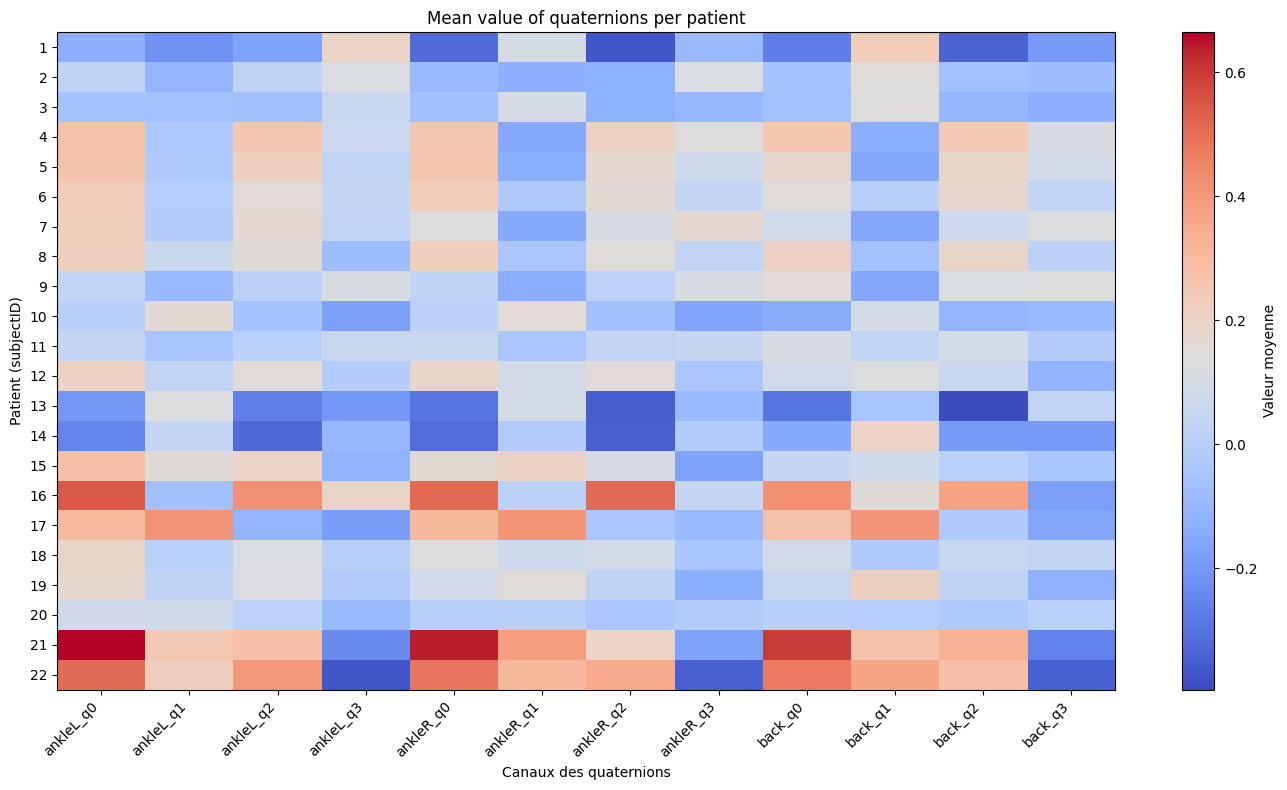

In [ ]:
df_quat_raw = pd.read_csv('sensor_data_quaternions.csv')

candidate_patient_cols = ['subjectID', 'Subject', 'subject']
patient_col = next((c for c in candidate_patient_cols if c in df_quat_raw.columns), None)
if patient_col is None:
    raise ValueError(
        f"Colonne patient introuvable. Colonnes disponibles: {list(df_quat_raw.columns)}"
    )

quat_columns = []
for col in df_quat_raw.columns:
    col_l = col.lower()
    is_quat = (
        'quat' in col_l
        or col_l.endswith('_q0')
        or col_l.endswith('_q1')
        or col_l.endswith('_q2')
        or col_l.endswith('_q3')
    )
    if is_quat and pd.api.types.is_numeric_dtype(df_quat_raw[col]):
        quat_columns.append(col)

if not quat_columns:
    raise ValueError(
        "Aucune colonne quaternion detectee. Verifie les noms de colonnes dans sensor_data_quaternions.csv."
    )

mean_quats_per_patient = df_quat_raw.groupby(patient_col)[quat_columns].mean().sort_index()

print('Moyenne des quaternions par patient:')
print(mean_quats_per_patient.round(4))

plt.figure(figsize=(14, 8))
plt.imshow(mean_quats_per_patient.values, aspect='auto', cmap='coolwarm')
plt.colorbar(label='Valeur moyenne')

plt.xticks(
    ticks=np.arange(len(mean_quats_per_patient.columns)),
    labels=mean_quats_per_patient.columns,
    rotation=45,
    ha='right'
 )
plt.yticks(
    ticks=np.arange(len(mean_quats_per_patient.index)),
    labels=mean_quats_per_patient.index
 )

plt.title('Mean value of quaternions per patient')
plt.xlabel('Canaux des quaternions')
plt.ylabel(f'Patient ({patient_col})')
plt.tight_layout()
plt.show()

Comparaison des moyennes quaternion: Normal vs FoG
           Normal_mean  FoG_mean  FoG_minus_Normal
ankleL_q0       0.1263    0.0023           -0.1240
ankleL_q1       0.0180   -0.1190           -0.1369
ankleL_q2       0.0656   -0.0002           -0.0658
ankleL_q3      -0.0091    0.1187            0.1277
ankleR_q0       0.0911   -0.1674           -0.2585
ankleR_q1       0.0132    0.0342            0.0210
ankleR_q2       0.0370   -0.1892           -0.2262
ankleR_q3      -0.0026   -0.0307           -0.0281
back_q0         0.0633   -0.1075           -0.1707
back_q1         0.0295    0.1939            0.1644
back_q2         0.0203   -0.0903           -0.1106
back_q3        -0.0259   -0.1204           -0.0944


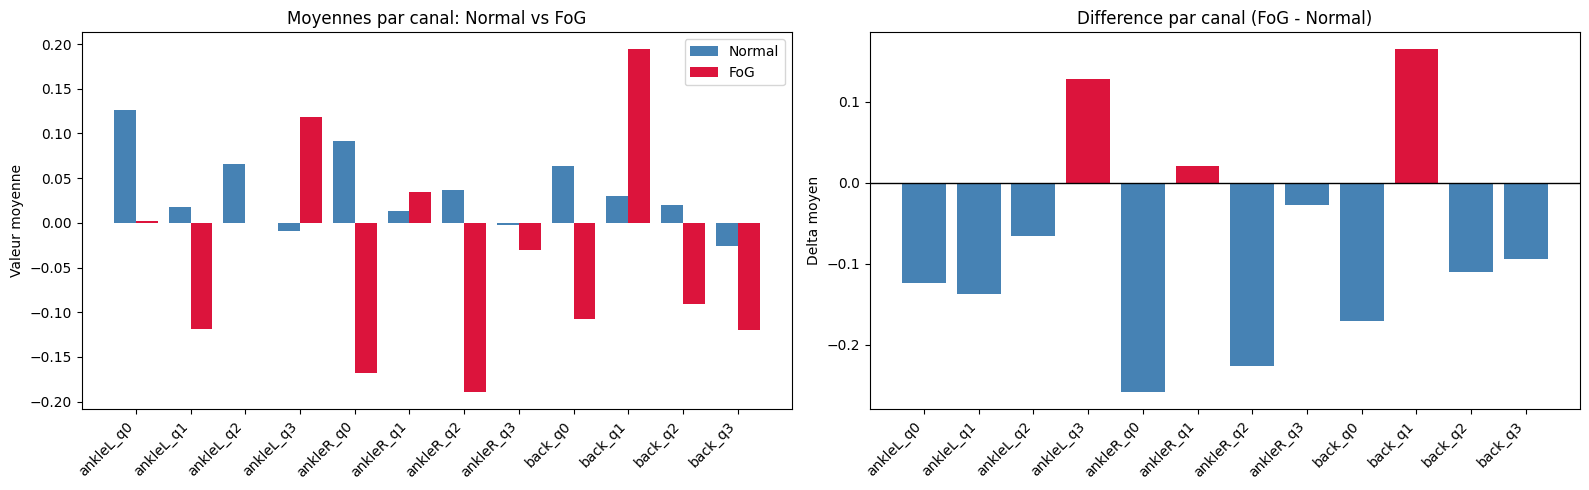

In [ ]:
df_q = pd.read_csv('sensor_data_quaternions.csv')

if 'fog' in df_q.columns:
    y_bin = df_q['fog'].astype(int)
elif 'fog_severity' in df_q.columns:
    y_bin = (df_q['fog_severity'] > 0).astype(int)
else:
    raise ValueError("Aucune colonne label trouvee (fog ou fog_severity).")

# Detecter les colonnes quaternion
quat_cols = []
for col in df_q.columns:
    col_l = col.lower()
    if (
        ('quat' in col_l)
        or col_l.endswith('_q0')
        or col_l.endswith('_q1')
        or col_l.endswith('_q2')
        or col_l.endswith('_q3')
    ):
        if pd.api.types.is_numeric_dtype(df_q[col]):
            quat_cols.append(col)

if not quat_cols:
    raise ValueError('Aucune colonne quaternion detectee.')

# Moyennes par classe
mean_normal = df_q.loc[y_bin == 0, quat_cols].mean()
mean_fog = df_q.loc[y_bin == 1, quat_cols].mean()
delta_fog_minus_normal = mean_fog - mean_normal

comparison = pd.DataFrame({
    'Normal_mean': mean_normal,
    'FoG_mean': mean_fog,
    'FoG_minus_Normal': delta_fog_minus_normal
}).sort_index()

print('Comparaison des moyennes quaternion: Normal vs FoG')
print(comparison.round(4))

# Graphiques
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(quat_cols))
w = 0.4
axes[0].bar(x - w/2, mean_normal.values, width=w, label='Normal', color='steelblue')
axes[0].bar(x + w/2, mean_fog.values, width=w, label='FoG', color='crimson')
axes[0].set_title('Moyennes par canal: Normal vs FoG')
axes[0].set_xticks(x)
axes[0].set_xticklabels(quat_cols, rotation=45, ha='right')
axes[0].set_ylabel('Valeur moyenne')
axes[0].legend()

# 2) Difference FoG - Normal
colors = ['crimson' if v > 0 else 'steelblue' for v in delta_fog_minus_normal.values]
axes[1].bar(x, delta_fog_minus_normal.values, color=colors)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Difference par canal (FoG - Normal)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(quat_cols, rotation=45, ha='right')
axes[1].set_ylabel('Delta moyen')

plt.tight_layout()
plt.show()

Colonne activité utilisée: activity
Nb fenêtres évaluées: 1782


,activity_id,activity_name,n_windows,fog_prevalence_%,accuracy,precision,recall,f1_score,TP,FP,FN,TN,mean_p_fog
0,1,Walking,801,7.365793,0.935081,0.612903,0.322034,0.422222,19,12,40,730,0.031640
1,2,Sit,37,0.000000,1.000000,0.000000,0.000000,0.000000,0,0,0,37,0.015840
2,3,Stand,278,1.079137,0.787770,0.048387,1.000000,0.092308,3,59,0,216,0.268951
3,4,Sit-to-Stand,12,0.000000,1.000000,0.000000,0.000000,0.000000,0,0,0,12,0.000458
4,5,Stand-to-Sit,18,5.555556,0.944444,0.000000,0.000000,0.000000,0,0,1,17,0.028647
5,6,Turn Right,187,43.850267,0.860963,0.833333,0.853659,0.843373,70,14,12,91,0.304271
6,7,Turn Left,449,54.565702,0.824053,0.880734,0.783673,0.829374,192,26,53,178,0.354613


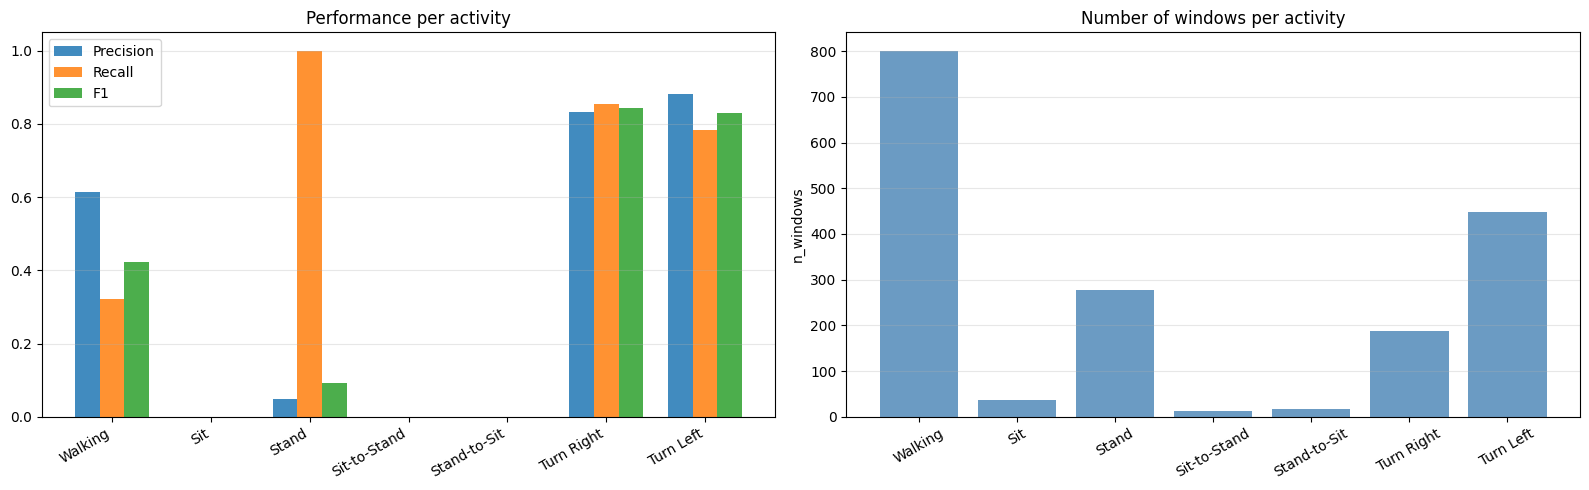


Résumé rapide:
activity_name  n_windows  fog_prevalence_%  precision   recall  f1_score
   Turn Right        187         43.850267   0.833333 0.853659  0.843373
    Turn Left        449         54.565702   0.880734 0.783673  0.829374
      Walking        801          7.365793   0.612903 0.322034  0.422222
        Stand        278          1.079137   0.048387 1.000000  0.092308
          Sit         37          0.000000   0.000000 0.000000  0.000000
 Sit-to-Stand         12          0.000000   0.000000 0.000000  0.000000
 Stand-to-Sit         18          5.555556   0.000000 0.000000  0.000000


In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

ACTIVITY_MAP = {
    1: "Walking",
    2: "Sit",
    3: "Stand",
    4: "Sit-to-Stand",
    5: "Stand-to-Sit",
    6: "Turn Right",
    7: "Turn Left"
}

def segment_data_with_activity(df, subjects, w=2, o=0.75, fs=60,
                               label_col="fog", activity_col_candidates=("activity", "activityID", "task", "taskID")):
    """
    Segmente les fenêtres comme segment_data, mais retourne aussi l'activité dominante de chaque fenêtre.
    """
    # Colonnes capteurs (identiques à ton pipeline)
    sensor_cols = [
        "ankleL_q0", "ankleL_q1", "ankleL_q2", "ankleL_q3",
        "ankleR_q0", "ankleR_q1", "ankleR_q2", "ankleR_q3",
        "back_q0", "back_q1", "back_q2", "back_q3"
    ]

    # Détection robuste de la colonne activité
    activity_col = None
    for c in activity_col_candidates:
        if c in df.columns:
            activity_col = c
            break
    if activity_col is None:
        raise ValueError(
            f"Aucune colonne activité trouvée. Colonnes testées: {activity_col_candidates}\n"
            f"Colonnes disponibles: {list(df.columns)}"
        )

    win_size = int(w * fs)
    step = int(win_size * (1 - o))

    X, y, a = [], [], []

    for sub in subjects:
        sub_df = df[df["subjectID"] == sub].reset_index(drop=True)
        if sub_df.empty:
            continue

        data = sub_df[sensor_cols].values
        labels = sub_df[label_col].values
        acts = sub_df[activity_col].values

        for i in range(0, len(data) - win_size, step):
            window = data[i:i + win_size]
            window_rel = window - window[0]  # même preprocessing que ton training

            y_win = pd.Series(labels[i:i + win_size]).mode()[0]
            a_win = pd.Series(acts[i:i + win_size]).mode()[0]

            X.append(window_rel)
            y.append(y_win)
            a.append(a_win)

    return np.array(X), np.array(y), np.array(a), activity_col


subjects_eval = test_subjects
threshold = 0.3

# Segmentation avec activité
X_act, y_act, a_act, activity_col_name = segment_data_with_activity(
    df_quat, subjects_eval, w=2, o=0.75, fs=60
)

print(f"Colonne activité utilisée: {activity_col_name}")
print(f"Nb fenêtres évaluées: {len(X_act)}")

# Dataset / Loader
act_dataset = FogDataset(X_act, y_act)
act_loader = torch.utils.data.DataLoader(act_dataset, batch_size=256, shuffle=False)

# Prédictions modèle
model.eval()
all_probs = []
all_preds = []
all_true = []

with torch.no_grad():
    start = 0
    for inputs, labels in act_loader:
        inputs = inputs.to(device)
        outputs = model(inputs).squeeze()

        if outputs.dim() == 0:
            outputs = outputs.unsqueeze(0)

        # Robustesse: si le modèle sort des logits, on applique sigmoid
        if (outputs.min() < 0) or (outputs.max() > 1):
            probs = torch.sigmoid(outputs)
        else:
            probs = outputs

        preds = (probs > threshold).int()

        all_probs.extend(probs.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_true.extend(labels.cpu().numpy().astype(int).tolist())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds, dtype=int)
all_true = np.array(all_true, dtype=int)
all_act = a_act[:len(all_true)]  # alignement sécurité


rows = []
for act_id in sorted(np.unique(all_act)):
    mask = (all_act == act_id)

    y_t = all_true[mask]
    y_p = all_preds[mask]
    y_pr = all_probs[mask]

    if len(y_t) == 0:
        continue

    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()

    rows.append({
        "activity_id": int(act_id),
        "activity_name": ACTIVITY_MAP.get(int(act_id), f"Activity {int(act_id)}"),
        "n_windows": len(y_t),
        "fog_prevalence_%": 100 * y_t.mean(),
        "accuracy": accuracy_score(y_t, y_p),
        "precision": precision_score(y_t, y_p, zero_division=0),
        "recall": recall_score(y_t, y_p, zero_division=0),
        "f1_score": f1_score(y_t, y_p, zero_division=0),
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
        "mean_p_fog": float(np.mean(y_pr))
    })

perf_by_activity = pd.DataFrame(rows).sort_values("activity_id")
display(perf_by_activity)


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1) Precision / Recall / F1 par activité
x = np.arange(len(perf_by_activity))
w = 0.25
axes[0].bar(x - w, perf_by_activity["precision"], width=w, label="Precision", alpha=0.85)
axes[0].bar(x,     perf_by_activity["recall"],    width=w, label="Recall", alpha=0.85)
axes[0].bar(x + w, perf_by_activity["f1_score"],  width=w, label="F1", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(perf_by_activity["activity_name"], rotation=30, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Performance per activity")
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

# 2) Volume + prévalence FoG
axes[1].bar(perf_by_activity["activity_name"], perf_by_activity["n_windows"], alpha=0.8, color="steelblue")
axes[1].set_title("Number of windows per activity")
axes[1].set_ylabel("n_windows")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nRésumé rapide:")
print(perf_by_activity[["activity_name", "n_windows", "fog_prevalence_%", "precision", "recall", "f1_score"]]
      .sort_values("f1_score", ascending=False)
      .to_string(index=False))

## Performacance per fog severity level

Nb fenetres evaluees: 1782
Severites presentes: [0, 1, 2, 3]

PERFORMANCE PAR NIVEAU DE SEVERITE
 severity_id severity_name  n_windows  fog_prevalence_%  accuracy  precision   recall       f1  TP  FP  FN   TN  mean_p_fog
           0        No FoG       1392               0.0  0.920259        0.0 0.000000 0.000000   0 111   0 1281    0.086510
           1          Mild         15             100.0  0.200000        1.0 0.200000 0.333333   3   0  12    0    0.178752
           2      Moderate        115             100.0  0.713043        1.0 0.713043 0.832487  82   0  33    0    0.506263
           3        Severe        260             100.0  0.765385        1.0 0.765385 0.867102 199   0  61    0    0.523139


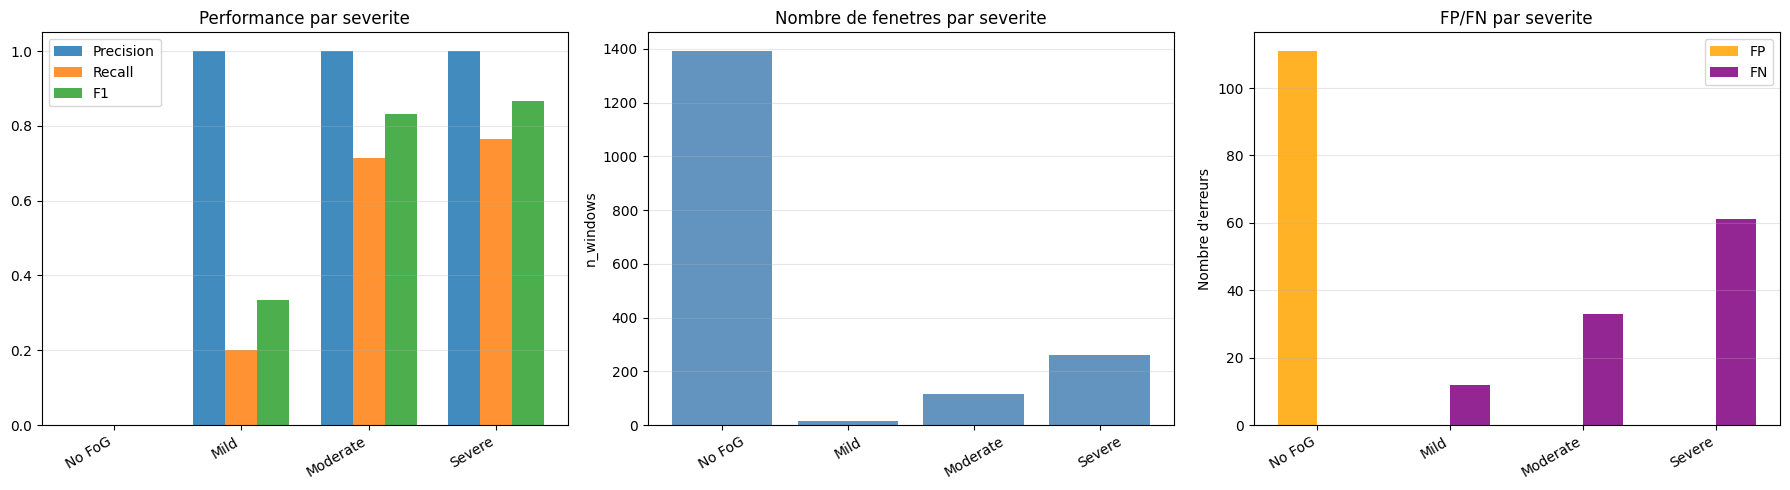


Resume:
- Meilleure severite: Severe (F1=0.867)
- Plus difficile: No FoG (F1=0.000)
- Compare bien n_windows et fog_prevalence_% pour eviter de sur-interpreter les severites rares.


In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# Tu peux adapter cette map selon ton dataset
SEVERITY_MAP = {
    0: 'No FoG',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe'
}

def build_quat_with_severity(df_quat, sensor_csv_path='sensor_data.csv'):
    """
    Retourne un dataframe avec quaternions + fog + fog_severity.
    Si fog_severity est deja present dans df_quat, on l'utilise directement.
    Sinon, merge robuste sur (subjectID, row_in_subject) avec sensor_data.csv.
    """
    if 'fog_severity' in df_quat.columns:
        return df_quat.copy()

    df_raw = pd.read_csv(sensor_csv_path)
    required = {'subjectID', 'fog_severity'}
    missing = required - set(df_raw.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes dans {sensor_csv_path}: {missing}")

    dq = df_quat.copy()
    dr = df_raw.copy()

    if 'subjectID' not in dq.columns:
        raise ValueError("subjectID manquant dans df_quat")

    dq['row_in_subject'] = dq.groupby('subjectID').cumcount()
    dr['row_in_subject'] = dr.groupby('subjectID').cumcount()

    merged = dq.merge(
        dr[['subjectID', 'row_in_subject', 'fog_severity']],
        on=['subjectID', 'row_in_subject'],
        how='left'
    ).drop(columns=['row_in_subject'])

    if merged['fog_severity'].isna().all():
        raise ValueError("Impossible d'aligner fog_severity avec les donnees quaternion")

    return merged


def segment_data_with_severity(df, subjects, w=2, o=0.75, fs=60):
    """
    Segmentation fenetres + label fog (mode) + severite fog (mode).
    """
    cols = [
        'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
        'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
        'back_q0', 'back_q1', 'back_q2', 'back_q3'
    ]

    for c in ['subjectID', 'fog', 'fog_severity']:
        if c not in df.columns:
            raise ValueError(f"Colonne manquante: {c}")

    win_size = int(w * fs)
    step = int(win_size * (1 - o))

    X, y, sev = [], [], []

    for sub in subjects:
        sub_df = df[df['subjectID'] == sub].reset_index(drop=True)
        if sub_df.empty:
            continue

        data = sub_df[cols].values
        labels = sub_df['fog'].values
        severity = sub_df['fog_severity'].values

        for i in range(0, len(data) - win_size, step):
            window = data[i:i + win_size]
            window_rel = window - window[0]

            y_mode = pd.Series(labels[i:i + win_size]).mode()[0]
            s_mode = pd.Series(severity[i:i + win_size]).mode()[0]

            X.append(window_rel)
            y.append(int(y_mode))
            sev.append(int(s_mode))

    return np.array(X), np.array(y), np.array(sev)


# -------------------------
# 1) Choix du split et preparation
# -------------------------
subjects_eval = test_subjects    # change en train_subjects / val_subjects / all_subjects si besoin
threshold = 0.3

df_quat_sev = build_quat_with_severity(df_quat, sensor_csv_path='sensor_data.csv')
X_sev, y_sev, sev_sev = segment_data_with_severity(df_quat_sev, subjects_eval, w=2, o=0.75, fs=60)

print(f"Nb fenetres evaluees: {len(X_sev)}")
print(f"Severites presentes: {sorted(np.unique(sev_sev).tolist())}")

sev_dataset = FogDataset(X_sev, y_sev)
sev_loader = torch.utils.data.DataLoader(sev_dataset, batch_size=256, shuffle=False)

# -------------------------
# 2) Predictions
# -------------------------
model.eval()
all_probs, all_preds, all_true = [], [], []

with torch.no_grad():
    for inputs, labels in sev_loader:
        inputs = inputs.to(device)
        outputs = model(inputs).squeeze()

        if outputs.dim() == 0:
            outputs = outputs.unsqueeze(0)

        # Robustesse si logits
        if (outputs.min() < 0) or (outputs.max() > 1):
            probs = torch.sigmoid(outputs)
        else:
            probs = outputs

        preds = (probs > threshold).int()

        all_probs.extend(probs.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_true.extend(labels.cpu().numpy().astype(int).tolist())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds, dtype=int)
all_true = np.array(all_true, dtype=int)
all_sev = sev_sev[:len(all_true)]

# -------------------------
# 3) Metriques par severite
# -------------------------
rows = []
for s in sorted(np.unique(all_sev)):
    mask = (all_sev == s)
    yt = all_true[mask]
    yp = all_preds[mask]
    ypr = all_probs[mask]

    if len(yt) == 0:
        continue

    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()

    rows.append({
        'severity_id': int(s),
        'severity_name': SEVERITY_MAP.get(int(s), f'Severity {int(s)}'),
        'n_windows': len(yt),
        'fog_prevalence_%': 100 * yt.mean(),
        'accuracy': accuracy_score(yt, yp),
        'precision': precision_score(yt, yp, zero_division=0),
        'recall': recall_score(yt, yp, zero_division=0),
        'f1': f1_score(yt, yp, zero_division=0),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
        'mean_p_fog': float(np.mean(ypr))
    })

perf_sev_df = pd.DataFrame(rows).sort_values('severity_id')

print("\n" + "=" * 80)
print("PERFORMANCE PAR NIVEAU DE SEVERITE")
print("=" * 80)
print(perf_sev_df.to_string(index=False))

# -------------------------
# 4) Visualisations
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(perf_sev_df))
labels = perf_sev_df['severity_name']

# (a) Precision / Recall / F1
w = 0.25
axes[0].bar(x - w, perf_sev_df['precision'], width=w, label='Precision', alpha=0.85)
axes[0].bar(x,     perf_sev_df['recall'],    width=w, label='Recall', alpha=0.85)
axes[0].bar(x + w, perf_sev_df['f1'],        width=w, label='F1', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=30, ha='right')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Performance par severite')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

# (b) Volume de donnees par severite
axes[1].bar(labels, perf_sev_df['n_windows'], color='steelblue', alpha=0.85)
axes[1].set_title('Nombre de fenetres par severite')
axes[1].set_ylabel('n_windows')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

# (c) Erreurs FP/FN par severite
axes[2].bar(x - 0.15, perf_sev_df['FP'], width=0.3, label='FP', color='orange', alpha=0.85)
axes[2].bar(x + 0.15, perf_sev_df['FN'], width=0.3, label='FN', color='purple', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=30, ha='right')
axes[2].set_title('FP/FN par severite')
axes[2].set_ylabel('Nombre d\'erreurs')
axes[2].grid(axis='y', alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# -------------------------
# 5) Lecture rapide
# -------------------------
if not perf_sev_df.empty:
    worst = perf_sev_df.sort_values('f1').iloc[0]
    best = perf_sev_df.sort_values('f1', ascending=False).iloc[0]

    print("\nResume:")
    print(f"- Meilleure severite: {best['severity_name']} (F1={best['f1']:.3f})")
    print(f"- Plus difficile: {worst['severity_name']} (F1={worst['f1']:.3f})")
    print("- Compare bien n_windows et fog_prevalence_% pour eviter de sur-interpreter les severites rares.")